# Example 

In this notebook a simple case is presented in order to show the general scheme which has been followed. 
A 2 step Neural Network is considered for the forward model 

In [13]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


True

In [14]:
# For reproducibility purposes , we set the seed to a fixed number
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [15]:
# The high fidelity (true) function and the low fidelity (noisy version) function are introduced 
highfid = lambda x: np.sin(x)+0.5*np.sin(2*x)+0.3*np.sin(3*x)
lowfid=lambda x:highfid(x)+0.2*np.sin(20*x)+0.1*np.sin(10*x)+0.1*np.sin(30*x)-0.4*np.sin(3*x)


Nhf = 7 # number of points to train the High Fidelity model
Nlf = 30 # number of points to train the Low Fidelity model
N = Nhf + Nlf

# training and test data
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

# number of epochs
NepoLF = 2000
NepoHF = 750

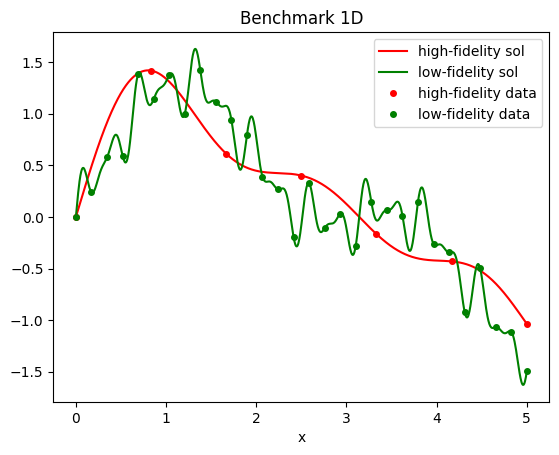

In [16]:
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

The low fidelity model can be seen as a noised version of the high fidelity model. In general, the data from a low fidelity model are easier or less expensive to be obtained

# Low-fidelity model

The function training took 12.030045747756958 seconds.


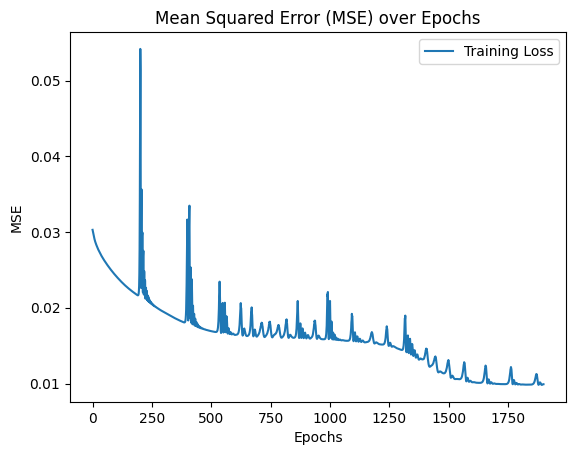

Test MSE: 0.09651147116930565
R^2: 0.7829948010554499


In [17]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'} 
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False) # Neural_network is the class that contains all the informations and the functions related to a Neural Network
yLF=modelLF.prediction(x_test) # associates to x_test the correspondent prediction of y using LF model
(mse_LF,R_LF)=modelLF.performance(x_test,highfid(x_test)) # quality test of the model

# High-fidelity model

The function training took 7.229218482971191 seconds.


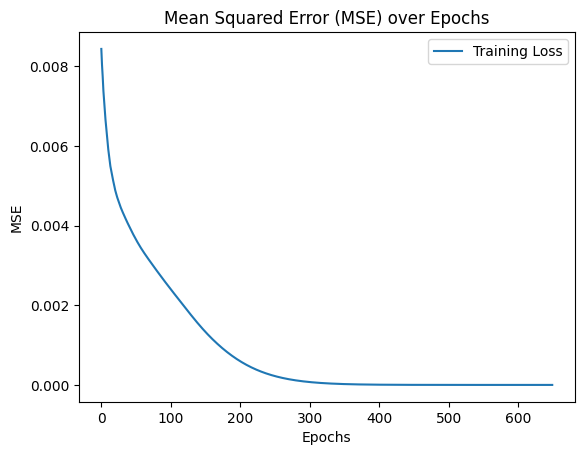

Test MSE: 0.08387025587656029
R^2: 0.8114184630954866


In [18]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R_HF)=modelHF.performance(x_test,highfid(x_test)) 

# 2 steps model 

The function training took 5.436534404754639 seconds.


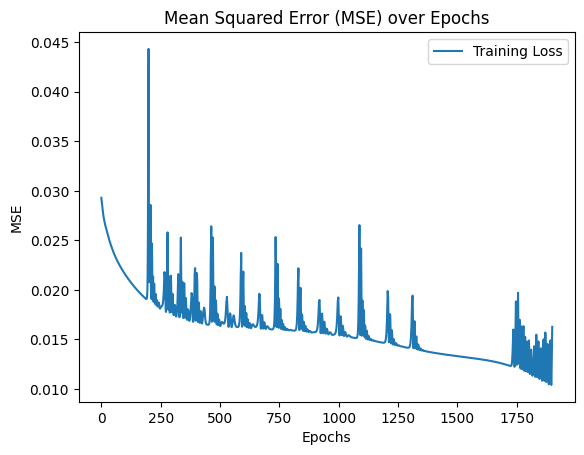

The function training took 1.900782585144043 seconds.


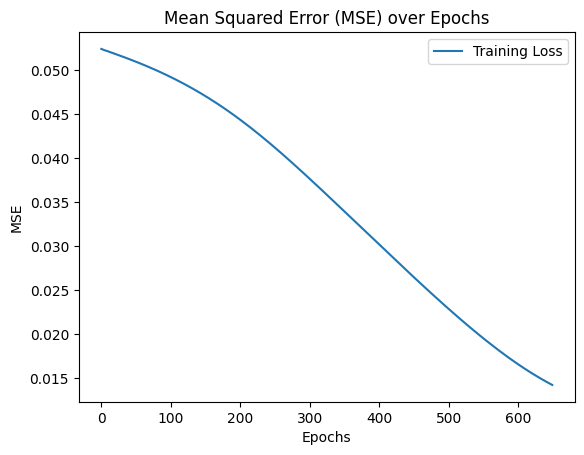

Test MSE: 0.014535307435652334
R^2: 0.967317488340214


In [19]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False) # Multifidelity connects different neural network classes, to build a multifidelity model
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

Text(0.5, 1.0, 'High fidelity model - 2-step')

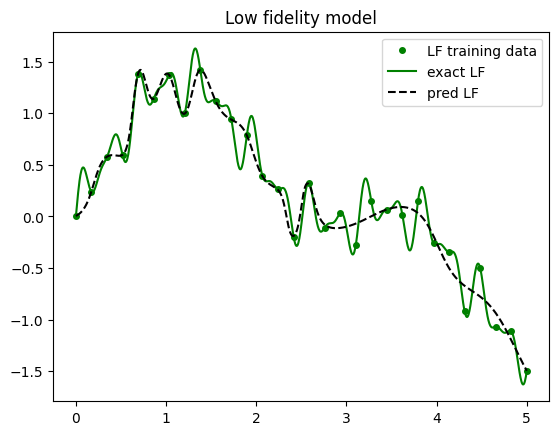

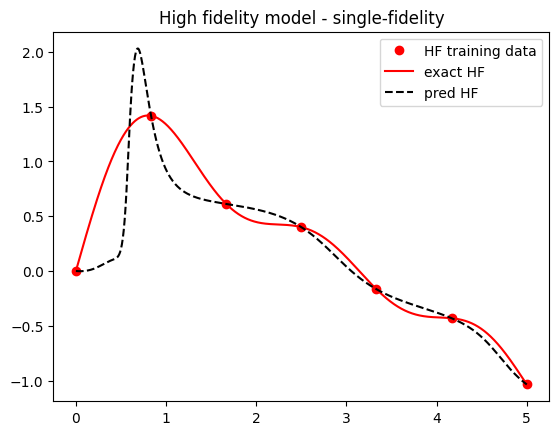

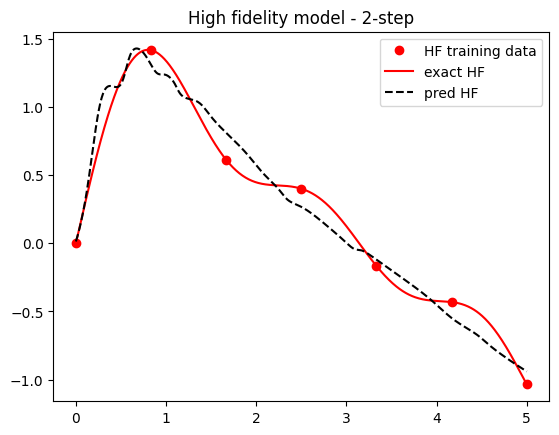

In [20]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

It is possible to notice that the 2 steps neural network has a better approximation of the original function w.r.t. the high fidelity model alone

## Markov Chain Monte Carlo

The Markov Chain Monte Carlo method, using Metropolis Hastings algorithm, is introduced in order to associate the most probable input to the given output

In [28]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.45
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =5000
burnin = 3000
n_chains=6

real values are [1. 2. 3. 4.]
Sampling chain 1/6


Running chain, α = 0.87: 100%|██████████| 5000/5000 [07:48<00:00, 10.67it/s]


Sampling chain 2/6


Running chain, α = 0.92: 100%|██████████| 5000/5000 [08:17<00:00, 10.06it/s]


Sampling chain 3/6


...

Sampling chain 5/6


Running chain, α = 0.88: 100%|██████████| 5000/5000 [08:16<00:00, 10.07it/s]


Sampling chain 6/6


Running chain, α = 0.90: 100%|██████████| 5000/5000 [08:39<00:00,  9.63it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.707 2.257 2.884 2.801]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.707  0.522   0.723    2.665      0.058    0.041      83.0     266.0   
x1  2.257  0.640   1.078    3.462      0.113    0.081      31.0      59.0   
x2  2.884  0.592   1.843    4.027      0.110    0.081      31.0      80.0   
x3  2.801  0.585   1.681    3.960      0.066    0.047      80.0     111.0   

    r_hat  
x0   1.05  
x1   1.15  
x2   1.13  
x3   1.10  
Autocorrelation...
the estimated values are [0.707 0.257 0.116 1.199]
 the difference between outputs of two models are [0.45030653 0.18340129 0.06895646 0.57098491]


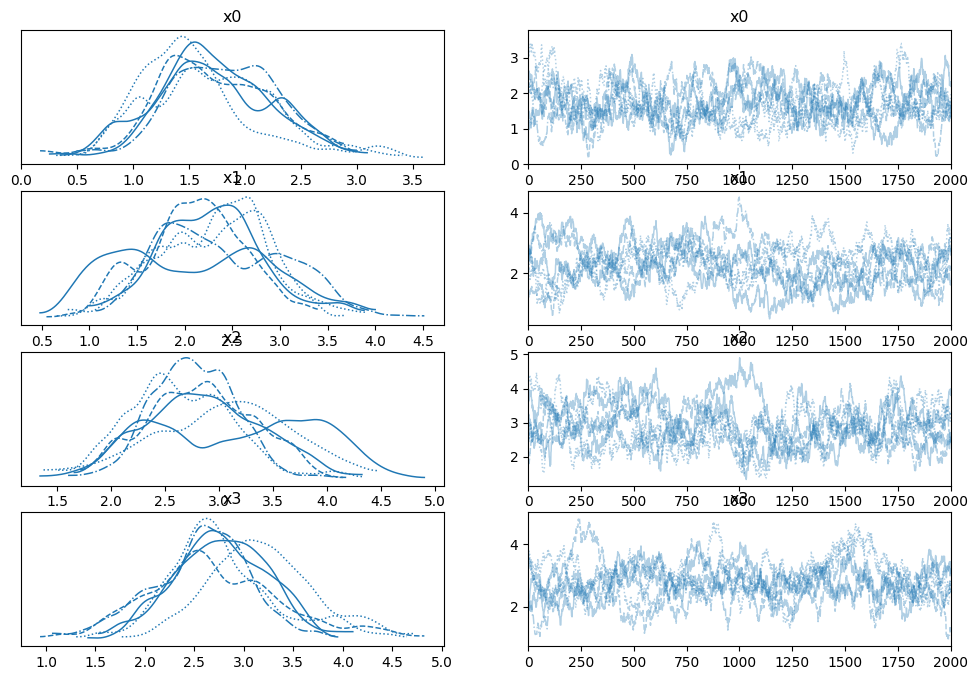

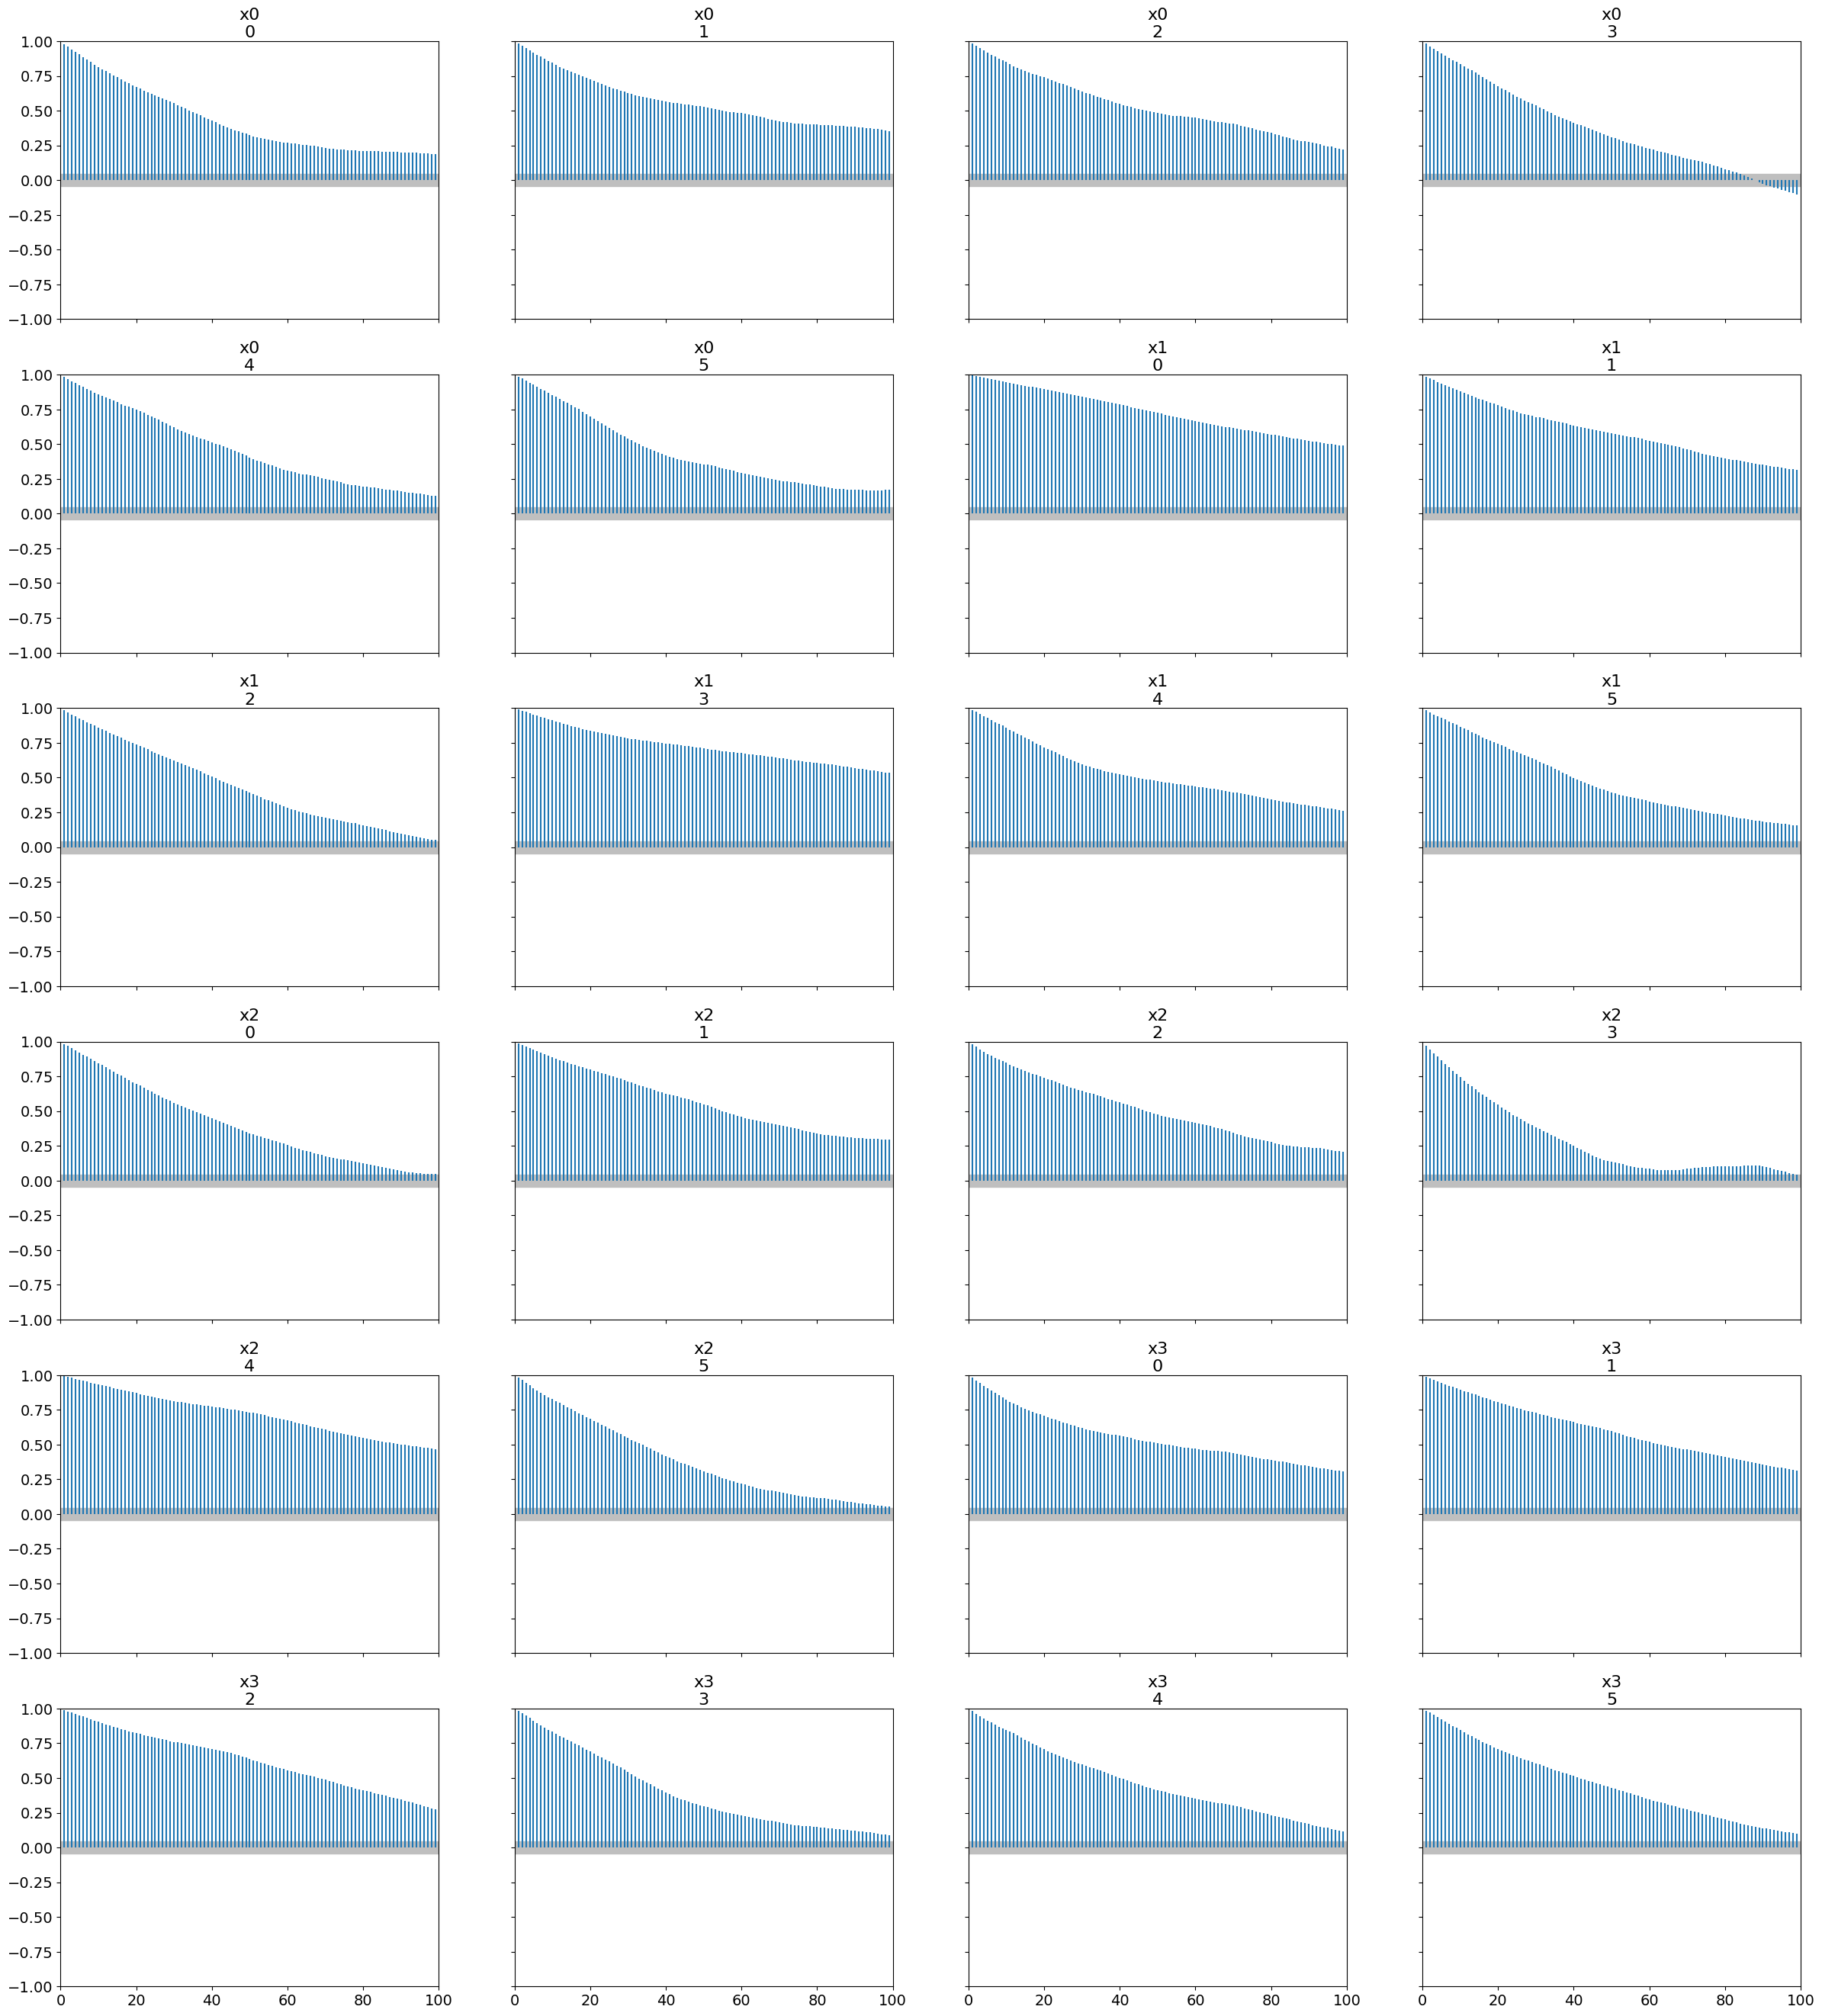

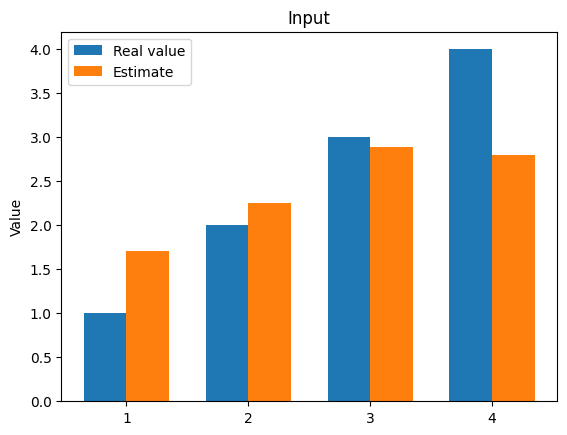

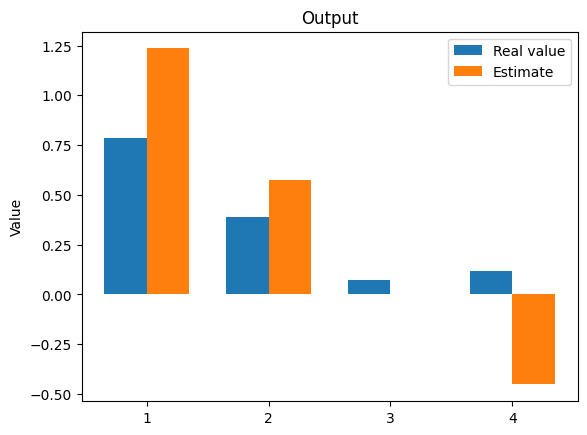

The function inverse took 3003.223361492157 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/6


Running chain, α = 0.87: 100%|██████████| 5000/5000 [04:14<00:00, 19.64it/s]


Sampling chain 2/6


Running chain, α = 0.84: 100%|██████████| 5000/5000 [03:52<00:00, 21.54it/s]


Sampling chain 3/6


...

Sampling chain 5/6


Running chain, α = 0.88: 100%|██████████| 5000/5000 [03:49<00:00, 21.81it/s]


Sampling chain 6/6


Running chain, α = 0.84: 100%|██████████| 5000/5000 [03:50<00:00, 21.72it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.435 2.253 2.618 2.821]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.435  0.721   1.213    3.833      0.098    0.070      56.0     117.0   
x1  2.253  0.691   1.202    3.771      0.089    0.063      63.0     197.0   
x2  2.618  0.642   1.534    3.871      0.131    0.095      24.0     134.0   
x3  2.821  0.507   2.018    3.900      0.069    0.052      75.0      86.0   

    r_hat  
x0   1.11  
x1   1.05  
x2   1.18  
x3   1.08  
Autocorrelation...
the estimated values are [1.435 0.253 0.382 1.179]
 the difference between outputs of two models are [1.5493315  0.28215283 0.3309453  0.14752185]


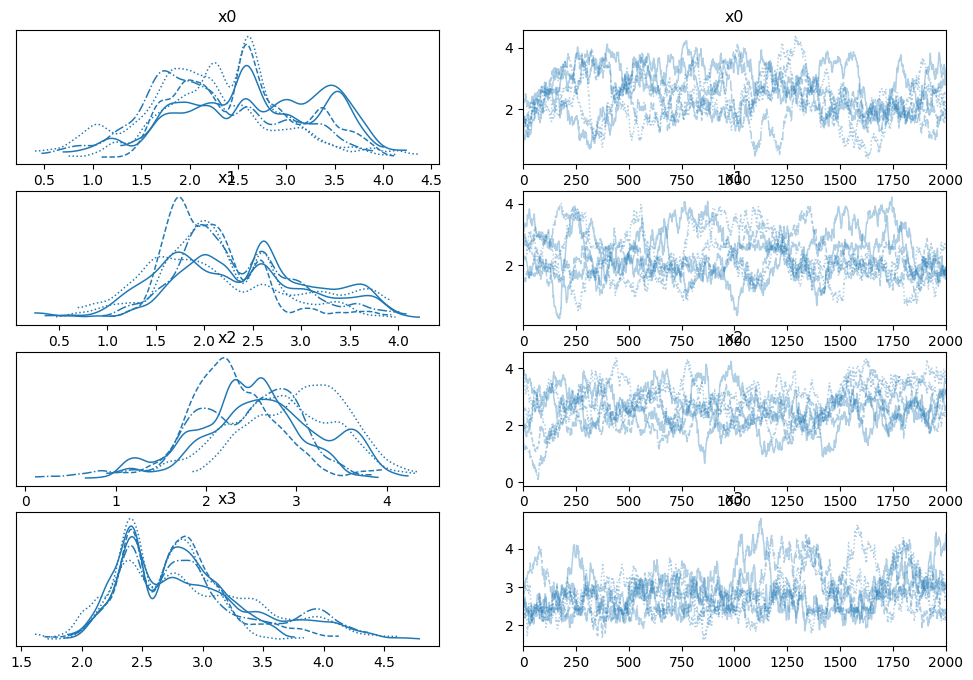

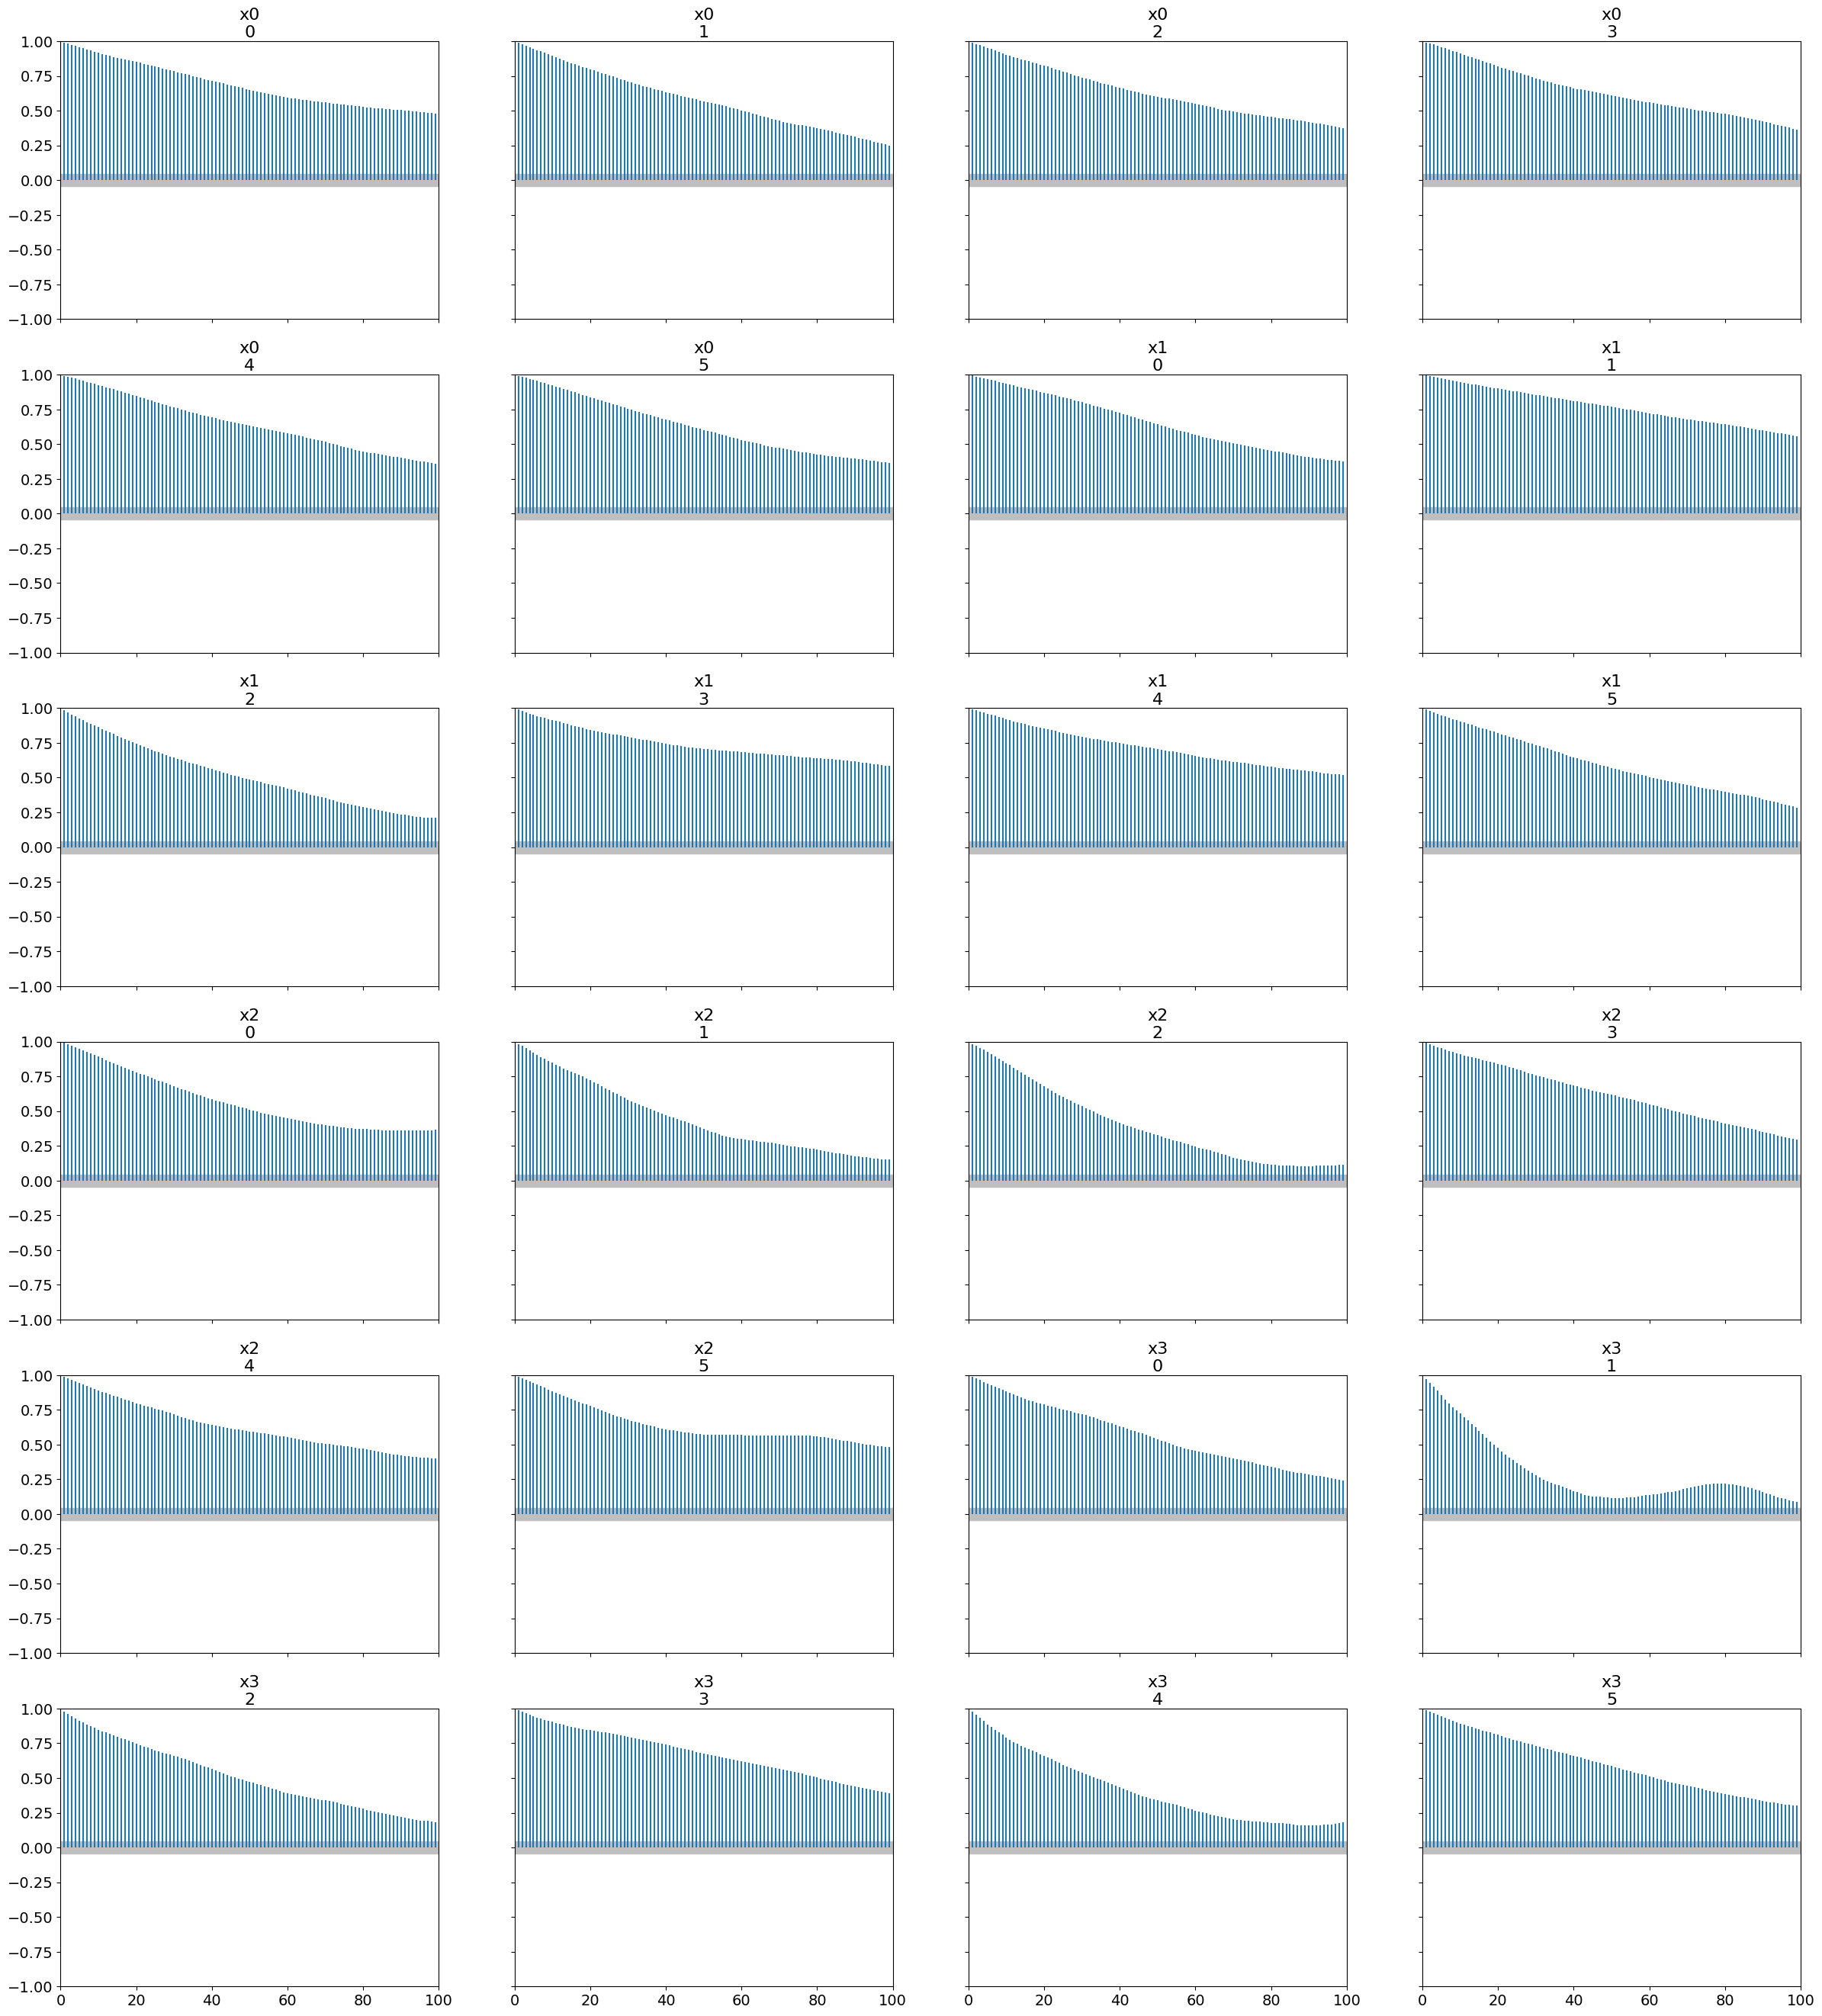

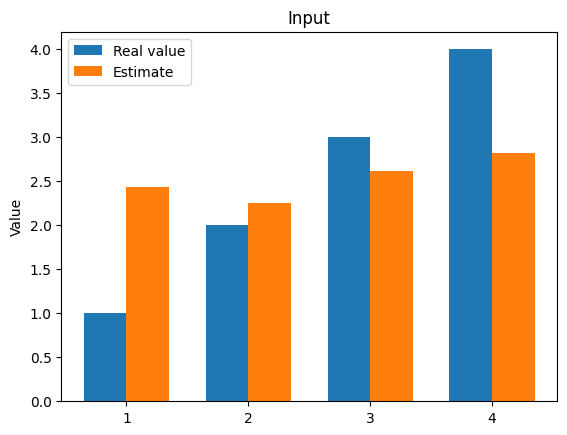

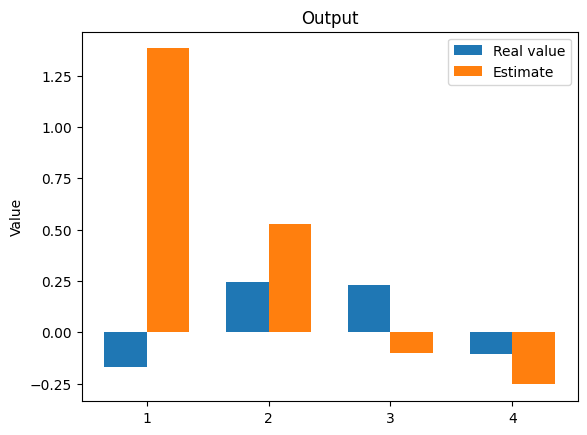

The function inverse took 1408.636519908905 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/6


Running chain, α = 0.89: 100%|██████████| 5000/5000 [04:09<00:00, 20.04it/s]


Sampling chain 2/6


Running chain, α = 0.88: 100%|██████████| 5000/5000 [04:17<00:00, 19.43it/s]


Sampling chain 3/6


...

Sampling chain 5/6


Running chain, α = 0.85: 100%|██████████| 5000/5000 [04:23<00:00, 18.99it/s]


Sampling chain 6/6


Running chain, α = 0.88: 100%|██████████| 5000/5000 [04:41<00:00, 17.74it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.105 2.712 2.888 2.886]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.105  0.575   1.071    3.259      0.113    0.081      26.0      30.0   
x1  2.712  0.633   1.499    3.870      0.104    0.074      39.0     218.0   
x2  2.888  0.633   1.666    4.031      0.071    0.050      80.0     174.0   
x3  2.886  0.647   1.684    4.162      0.108    0.079      36.0     143.0   

    r_hat  
x0   1.16  
x1   1.13  
x2   1.05  
x3   1.13  
Autocorrelation...
the estimated values are [1.105 0.712 0.112 1.114]
 the difference between outputs of two models are [0.3843432  0.29608178 0.08852769 0.50902694]


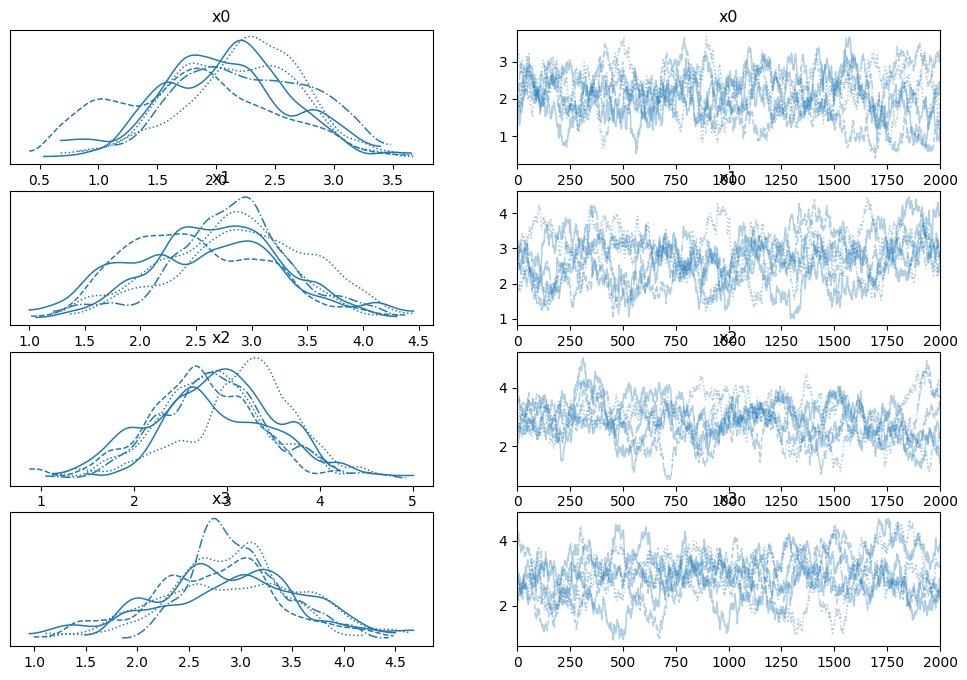

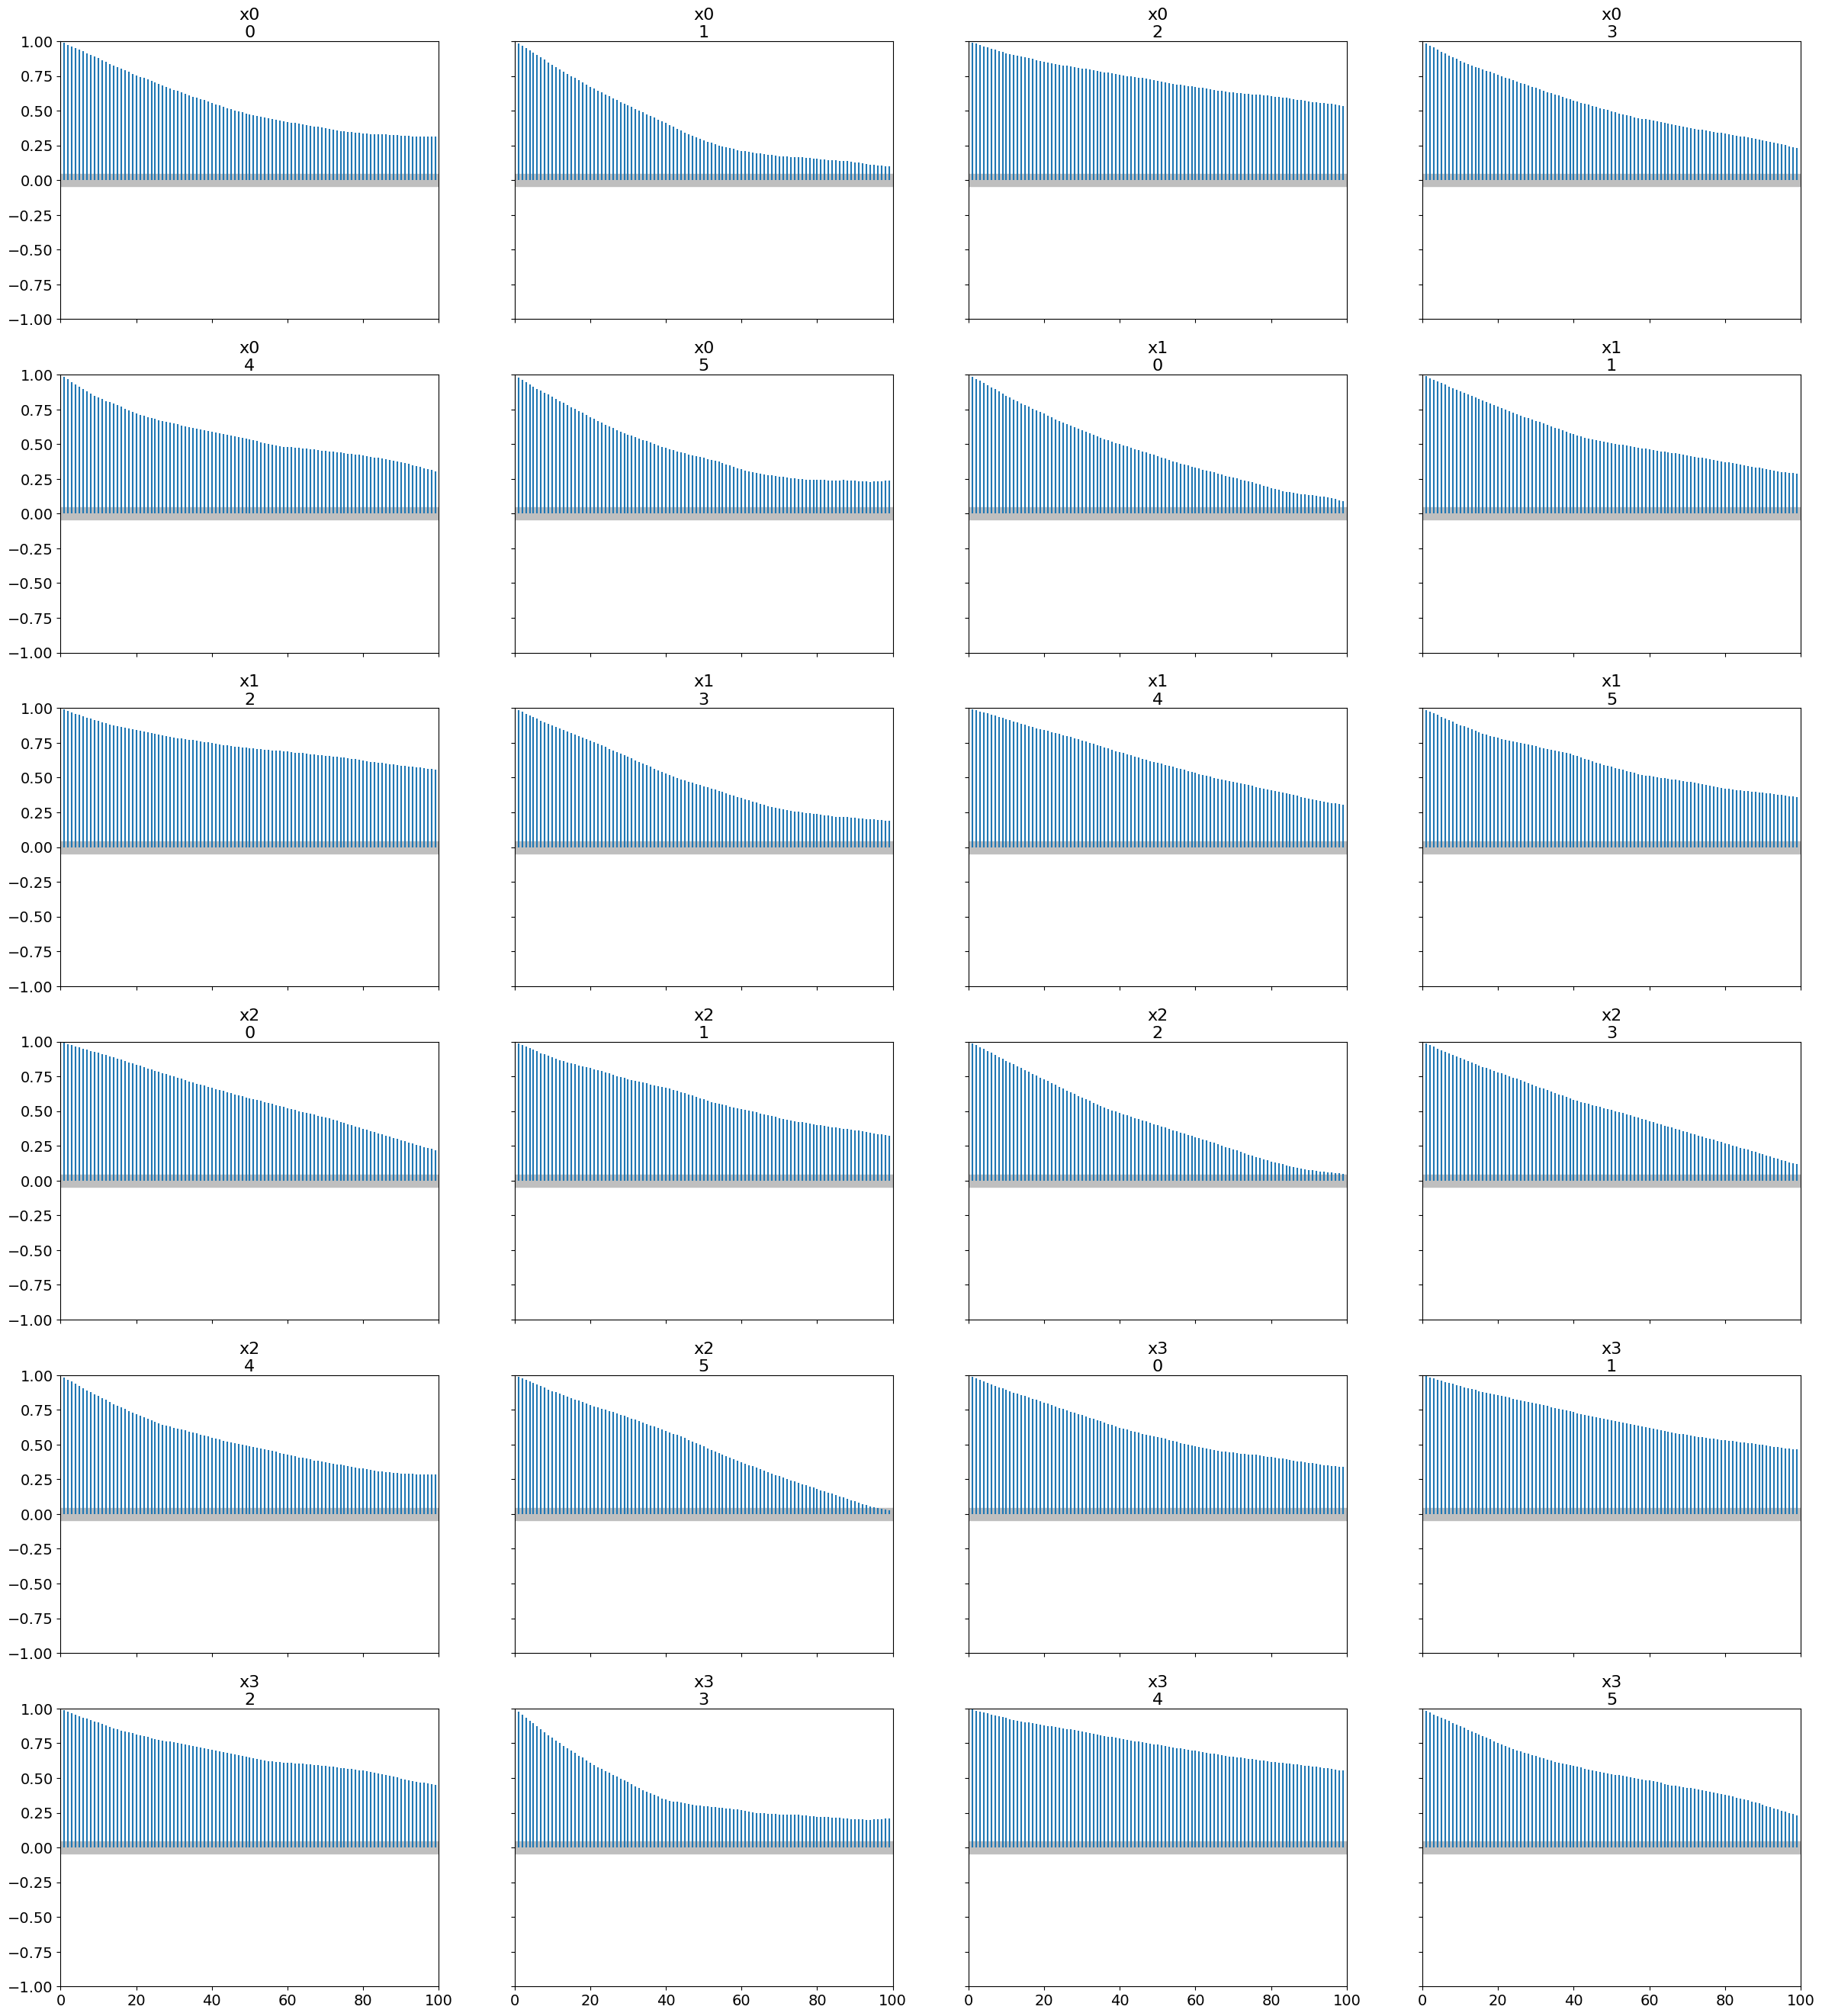

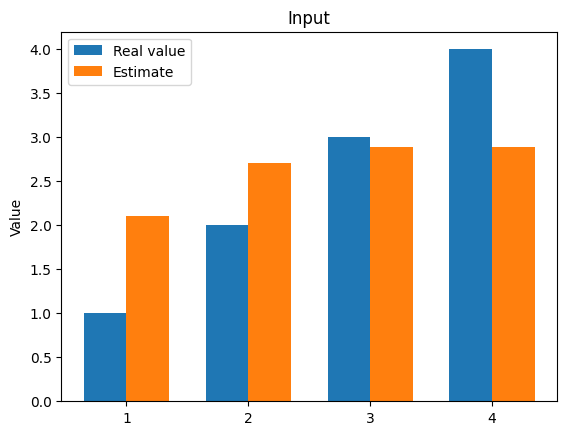

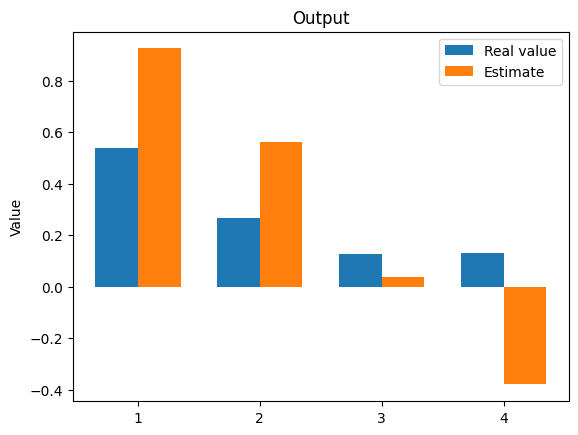

The function inverse took 1600.544960975647 seconds.


In [23]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)



real values are [1. 2. 3. 4.]
Sampling chain 1/6


Running chain, α = 0.35: 100%|██████████| 5000/5000 [07:57<00:00, 10.46it/s]


Sampling chain 2/6


Running chain, α = 0.44: 100%|██████████| 5000/5000 [07:51<00:00, 10.60it/s]


Sampling chain 3/6


...

Sampling chain 5/6


Running chain, α = 0.42: 100%|██████████| 5000/5000 [07:37<00:00, 10.93it/s]


Sampling chain 6/6


Running chain, α = 0.36: 100%|██████████| 5000/5000 [07:33<00:00, 11.03it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.993 2.411 2.651 2.802]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.993  0.629   0.813    3.150      0.024    0.017     698.0    1386.0   
x1  2.411  0.633   1.197    3.529      0.024    0.017     724.0    1012.0   
x2  2.651  0.616   1.501    3.745      0.023    0.016     698.0    1297.0   
x3  2.802  0.631   1.627    3.959      0.025    0.018     694.0     961.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Autocorrelation...
the estimated values are [0.993 0.411 0.349 1.198]
 the difference between outputs of two models are [0.65632027 0.27878898 0.19717302 0.57042558]


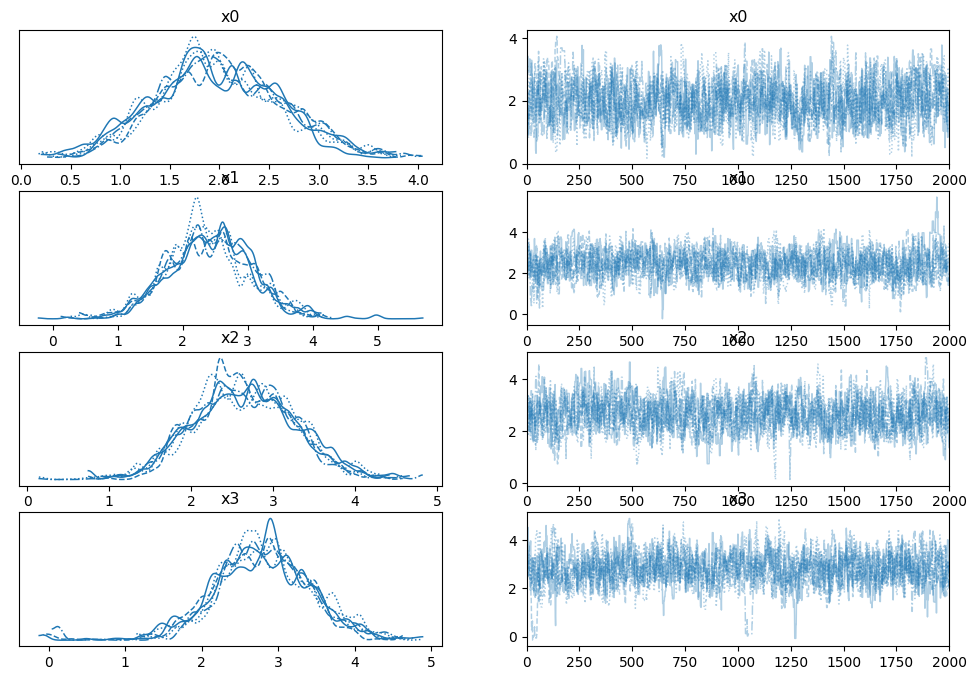

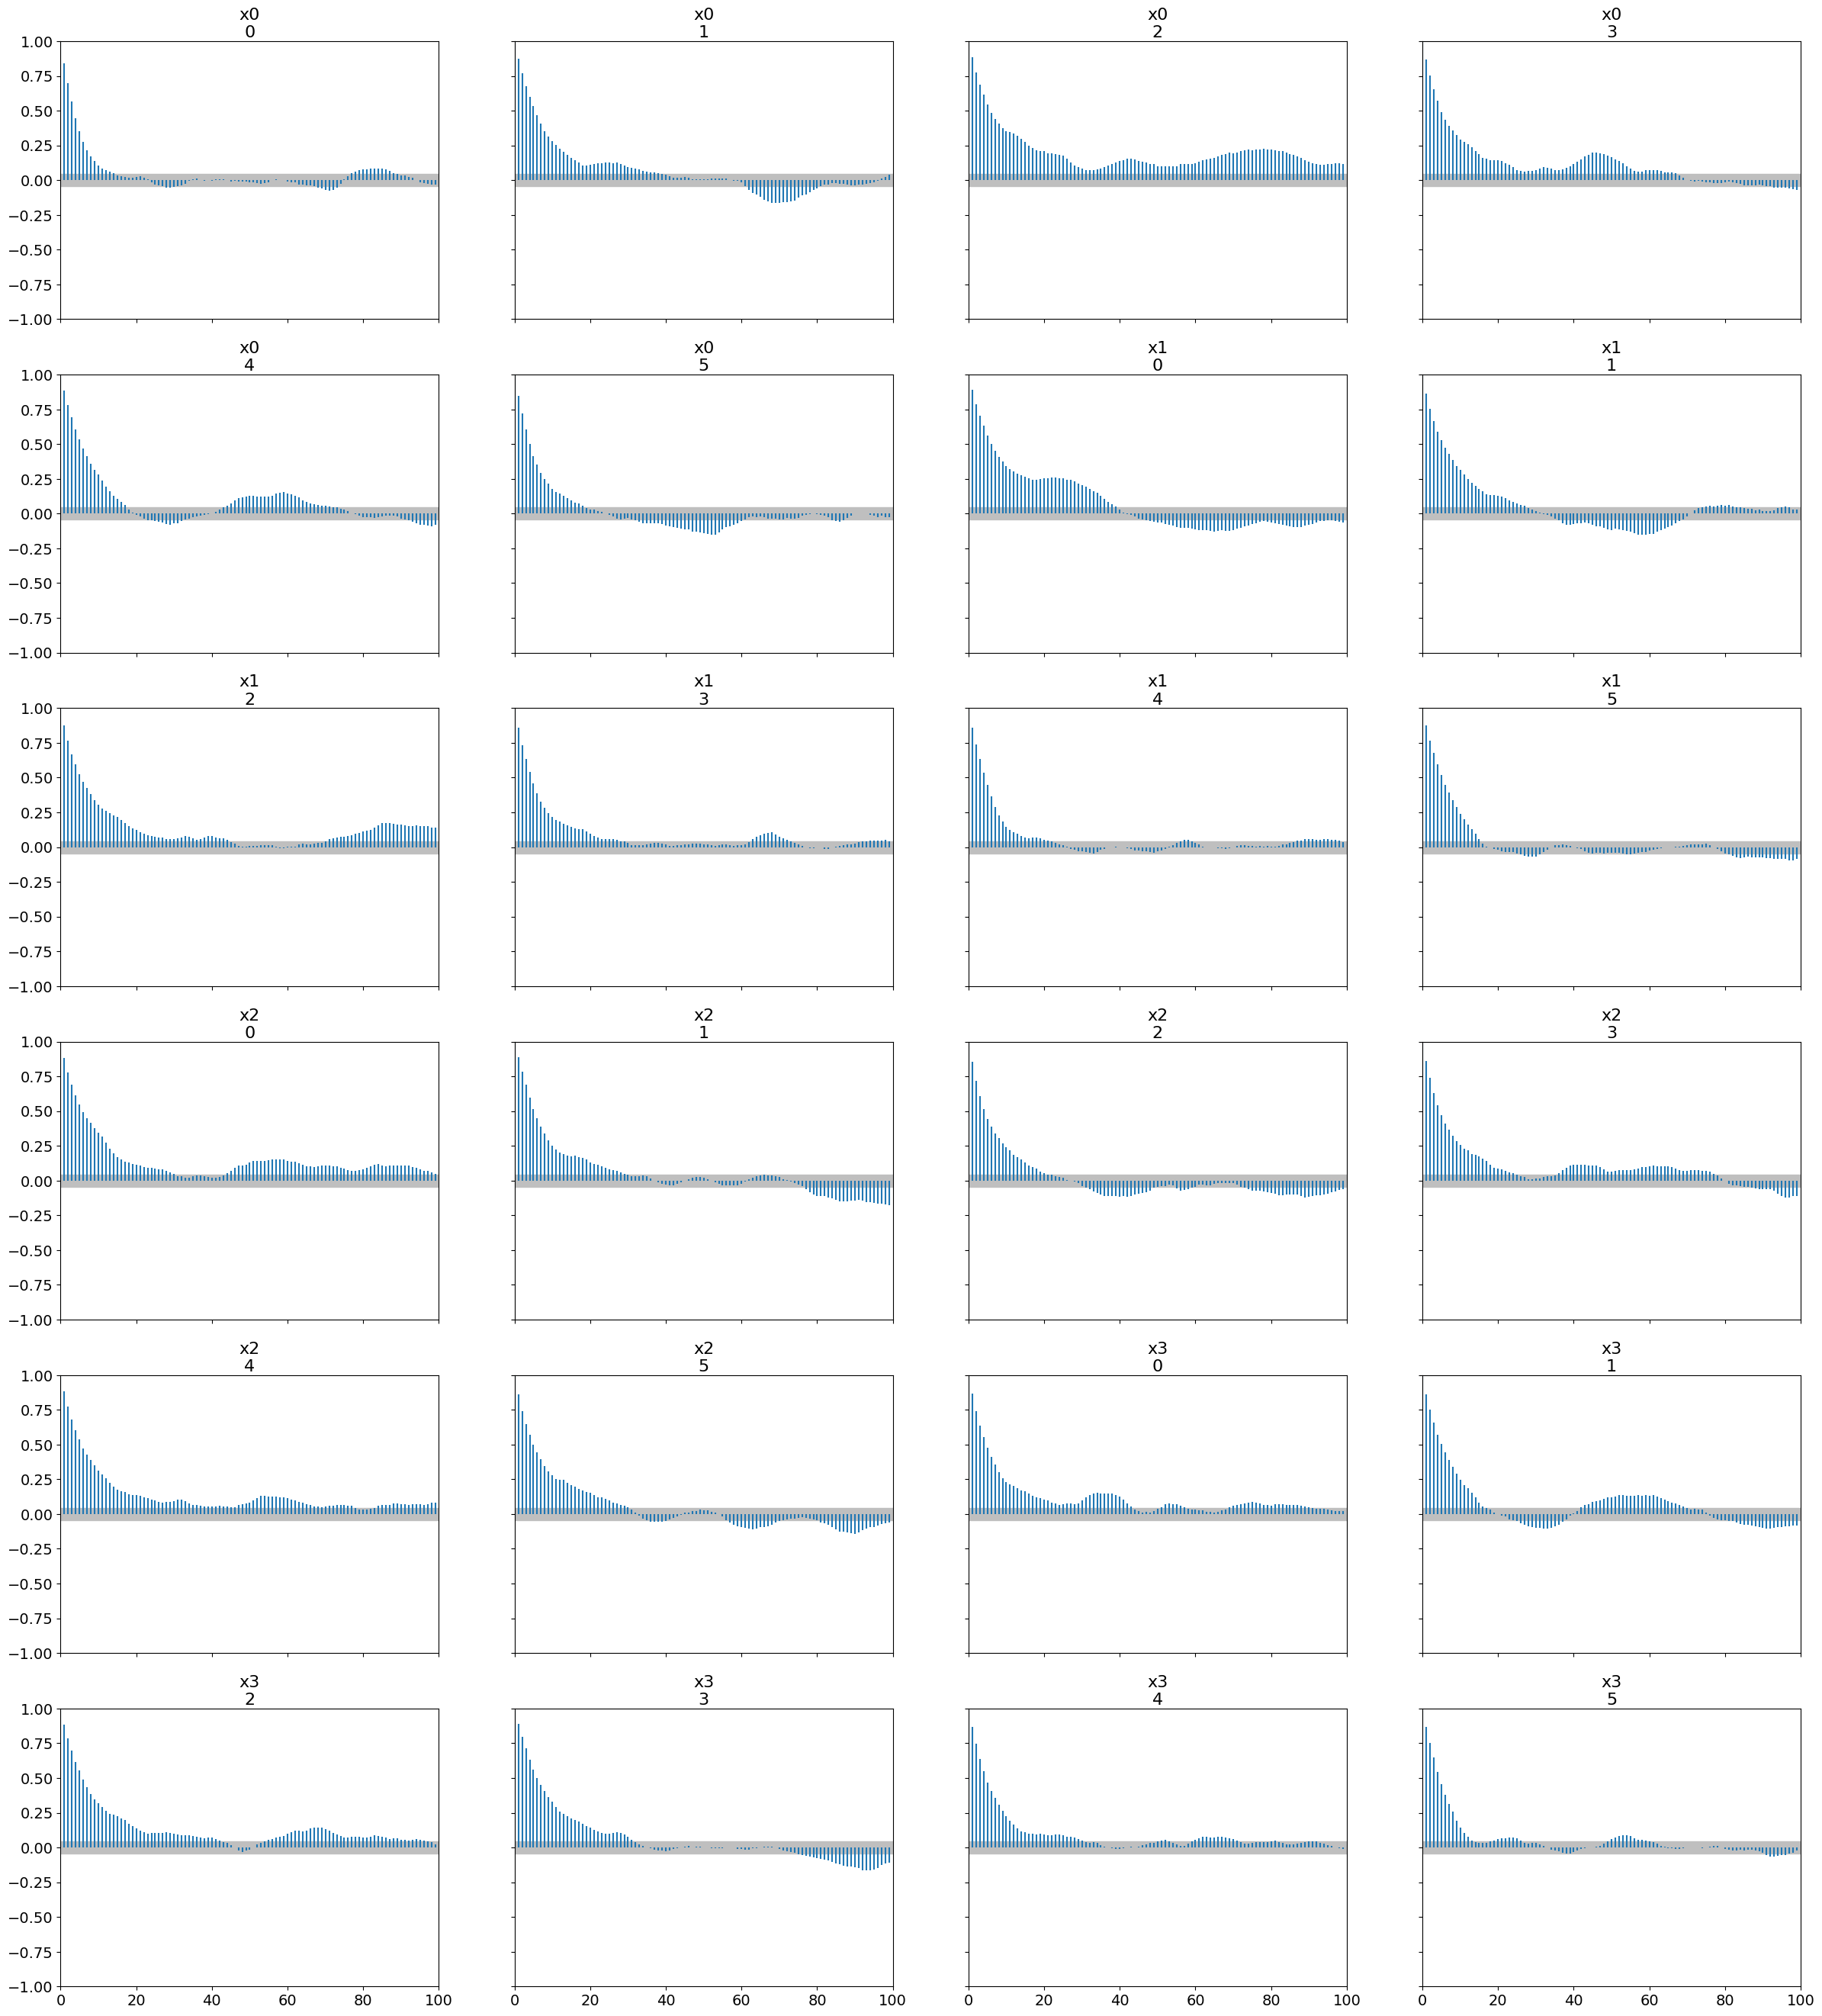

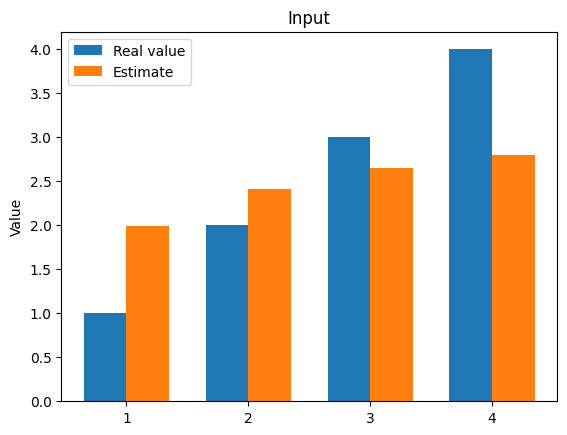

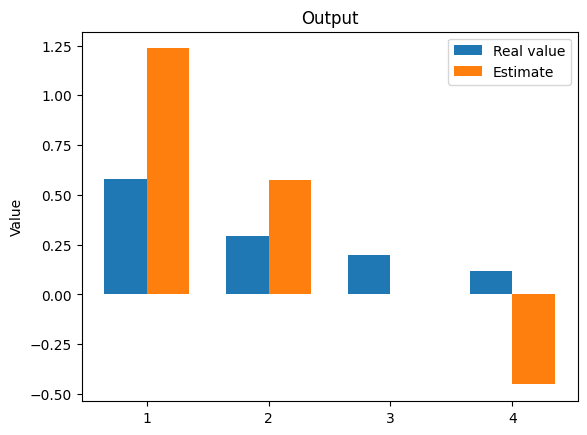

The function inverse took 2797.293425798416 seconds.


TypeError: Neural_Network.inverse() got an unexpected keyword argument 'algo'

In [29]:
estimate_MF2=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")
estimate_LF2=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")
estimate_HF2=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")



Higher standard deviation likelihood

In [26]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.9
cov_noise=0.1
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =5000
burnin = 3000
n_chains=4

real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.85: 100%|██████████| 5000/5000 [09:12<00:00,  9.06it/s]


Sampling chain 2/4


Running chain, α = 0.87: 100%|██████████| 5000/5000 [09:04<00:00,  9.18it/s]


Sampling chain 3/4


Running chain, α = 0.91: 100%|██████████| 5000/5000 [09:42<00:00,  8.58it/s]


Sampling chain 4/4


Running chain, α = 0.90: 100%|██████████| 5000/5000 [08:53<00:00,  9.37it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.085 2.425 2.425 2.546]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.085  0.643   0.889    3.242      0.095    0.069      46.0      97.0   
x1  2.425  0.588   1.316    3.584      0.100    0.076      35.0     145.0   
x2  2.425  0.599   1.364    3.610      0.072    0.052      71.0     130.0   
x3  2.546  0.685   1.166    3.845      0.103    0.074      46.0      70.0   

    r_hat  
x0   1.08  
x1   1.10  
x2   1.04  
x3   1.08  
Autocorrelation...
the estimated values are [1.085 0.425 0.575 1.454]
 the difference between outputs of two models are [0.72749555 0.28291968 0.28680997 0.70126291]


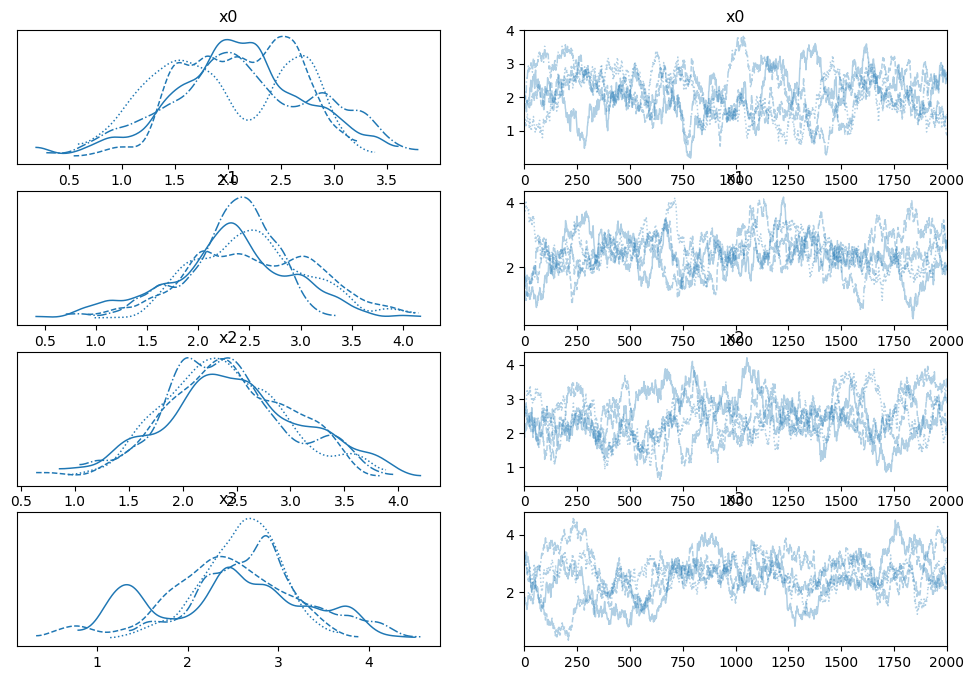

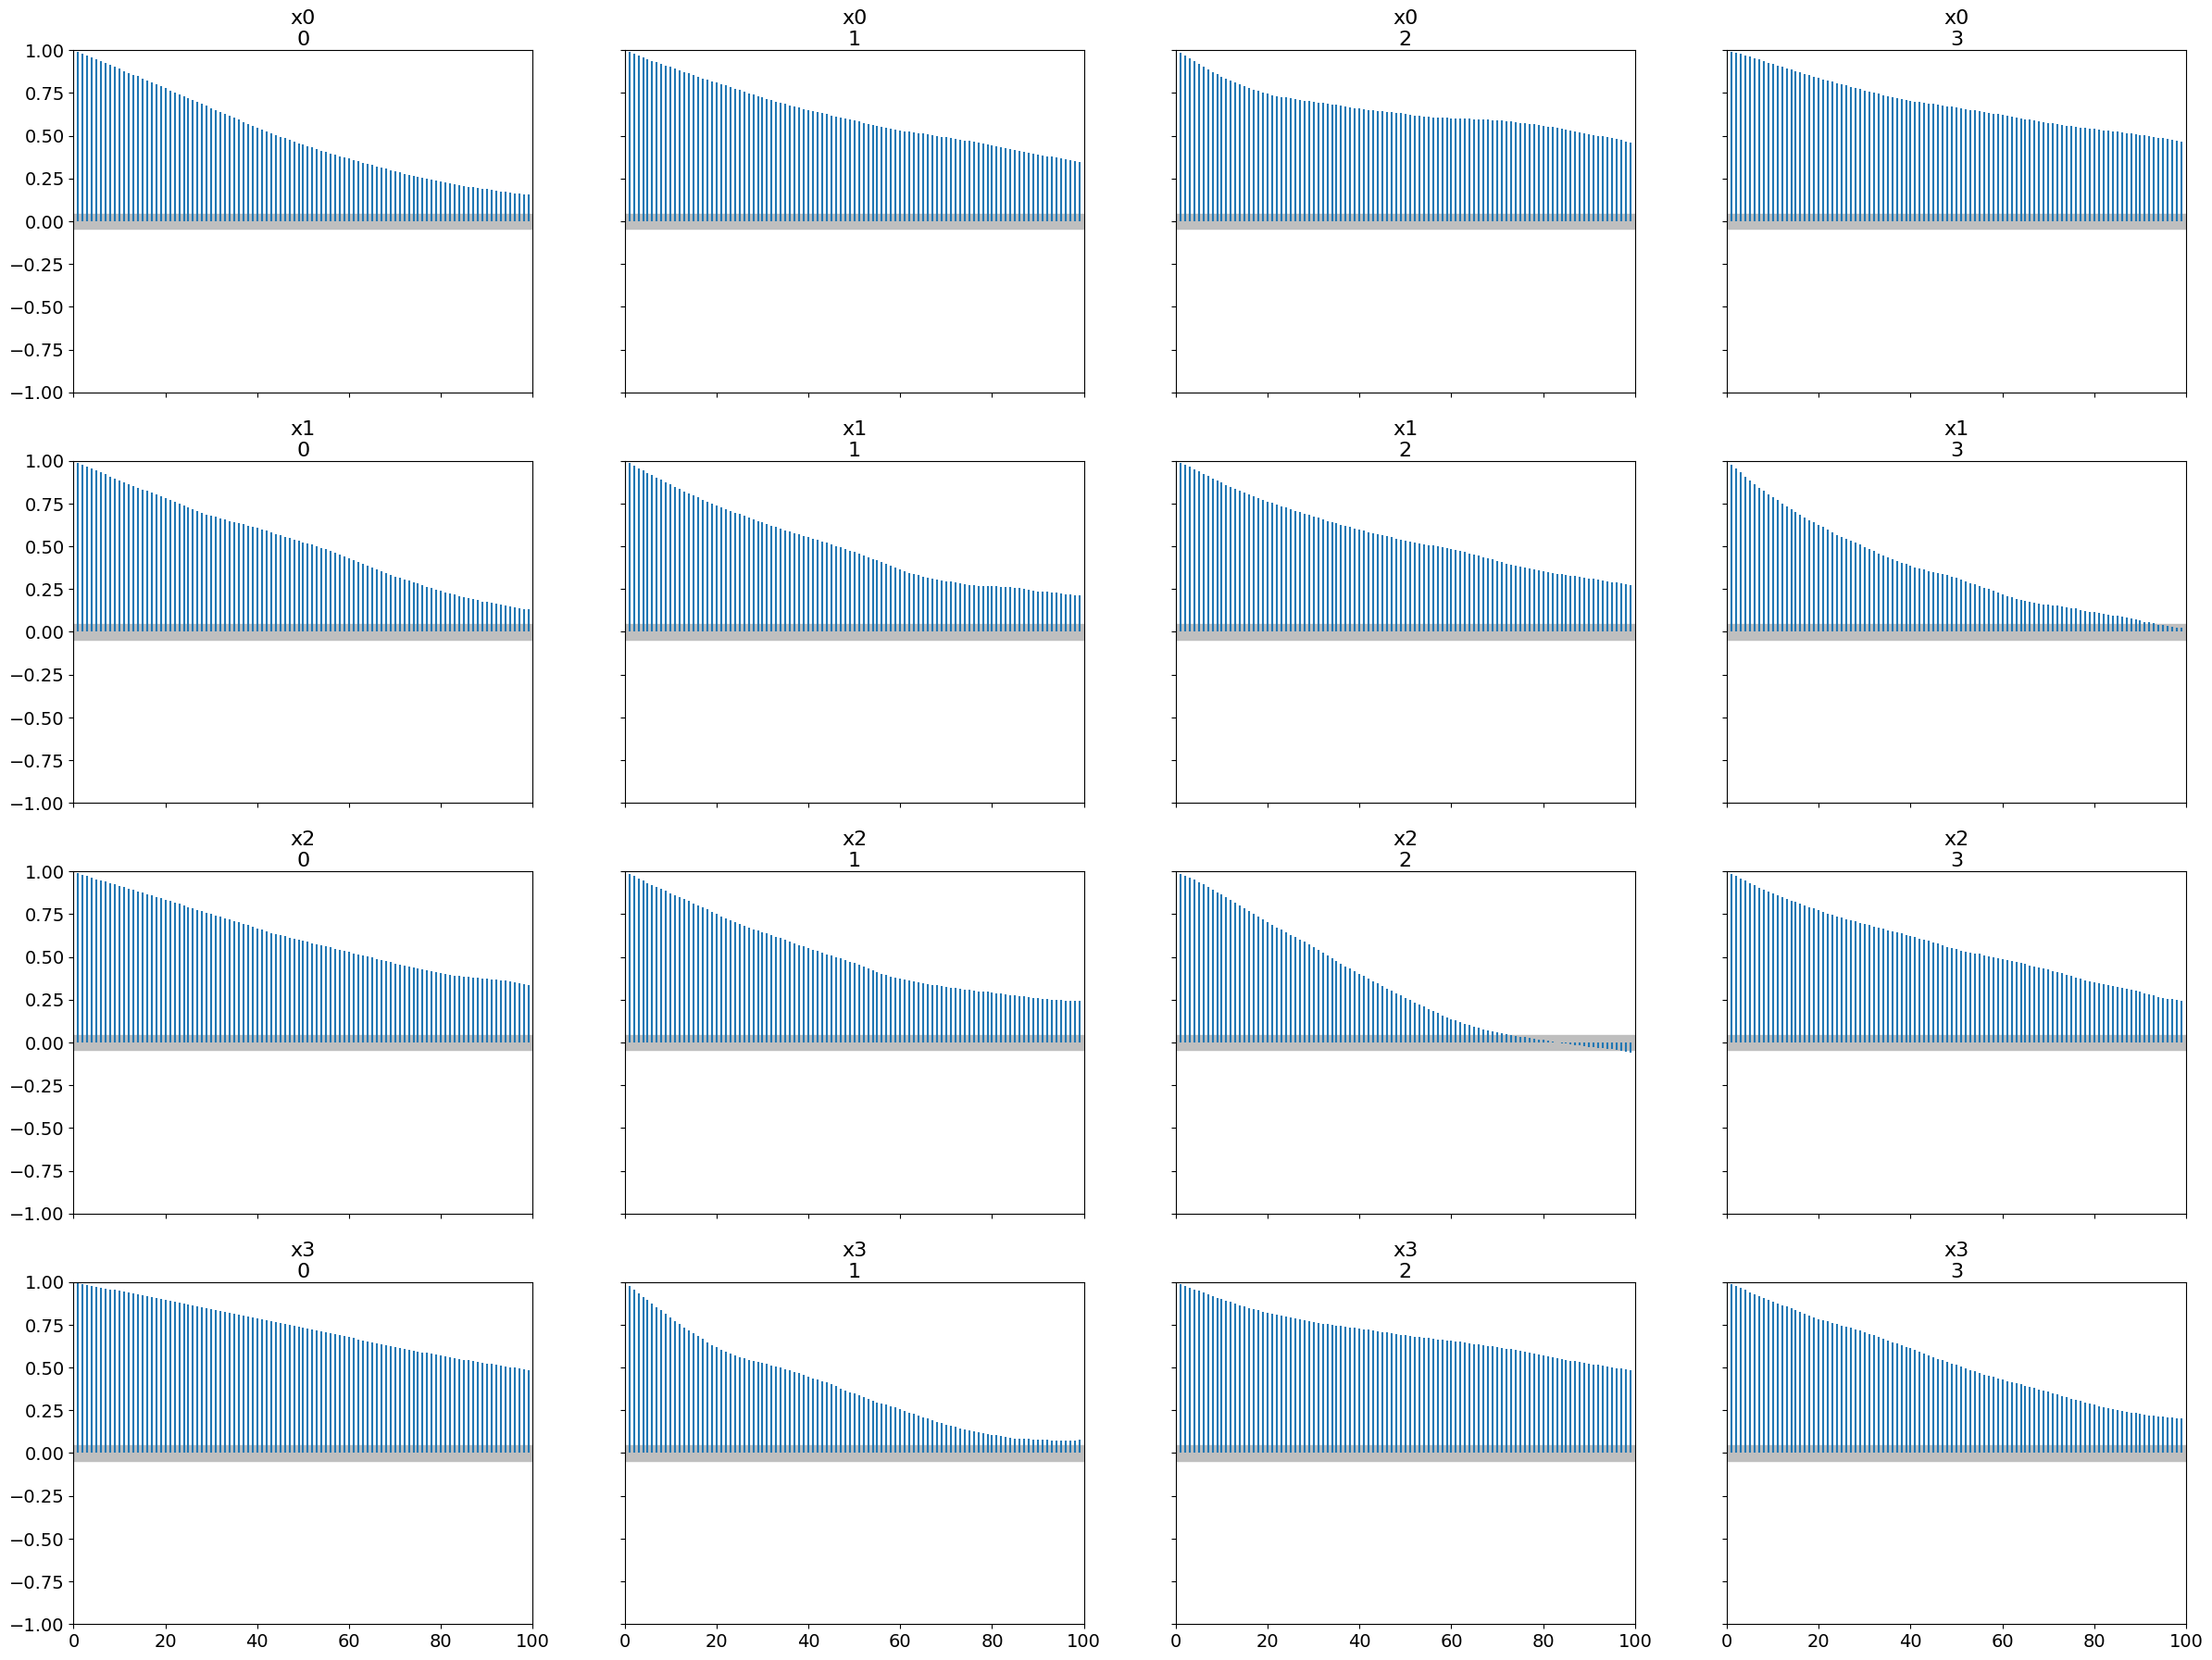

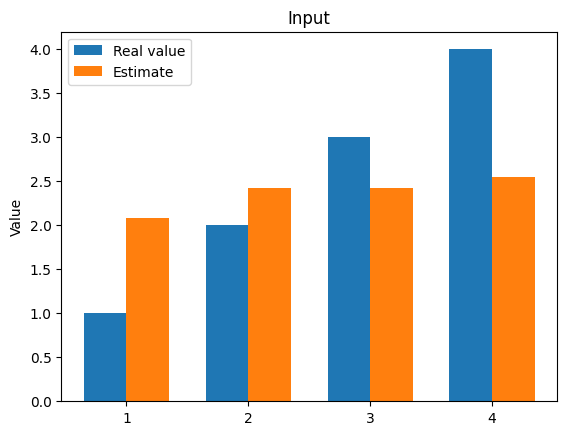

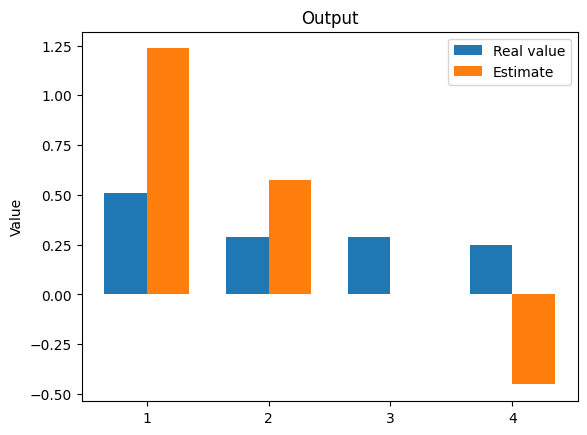

The function inverse took 2242.0666694641113 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.87: 100%|██████████| 5000/5000 [04:19<00:00, 19.24it/s]


Sampling chain 2/4


Running chain, α = 0.88: 100%|██████████| 5000/5000 [04:09<00:00, 20.03it/s]


Sampling chain 3/4


Running chain, α = 0.92: 100%|██████████| 5000/5000 [04:58<00:00, 16.73it/s]


Sampling chain 4/4


Running chain, α = 0.89: 100%|██████████| 5000/5000 [04:34<00:00, 18.19it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.139 2.603 2.625 2.485]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.139  0.670   1.133    3.633      0.112    0.082      40.0      93.0   
x1  2.603  0.670   1.357    3.831      0.097    0.069      48.0      99.0   
x2  2.625  0.623   1.424    3.843      0.099    0.071      40.0      92.0   
x3  2.485  0.491   1.600    3.413      0.082    0.058      34.0     134.0   

    r_hat  
x0   1.08  
x1   1.05  
x2   1.09  
x3   1.11  
Autocorrelation...
the estimated values are [1.139 0.603 0.375 1.515]
 the difference between outputs of two models are [1.0638739  0.25236464 0.30844298 0.26118115]


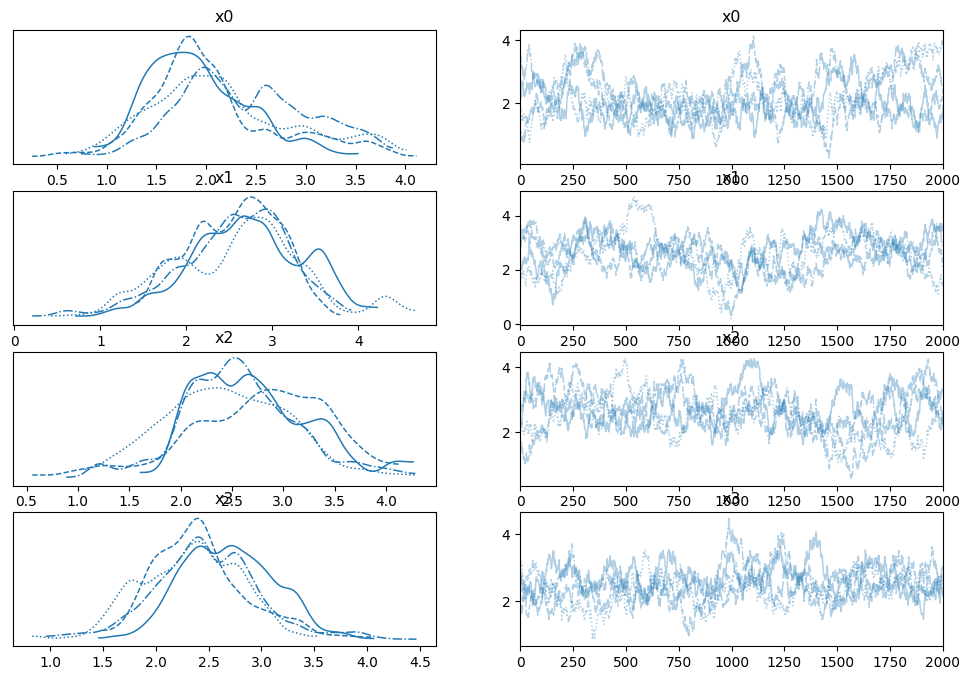

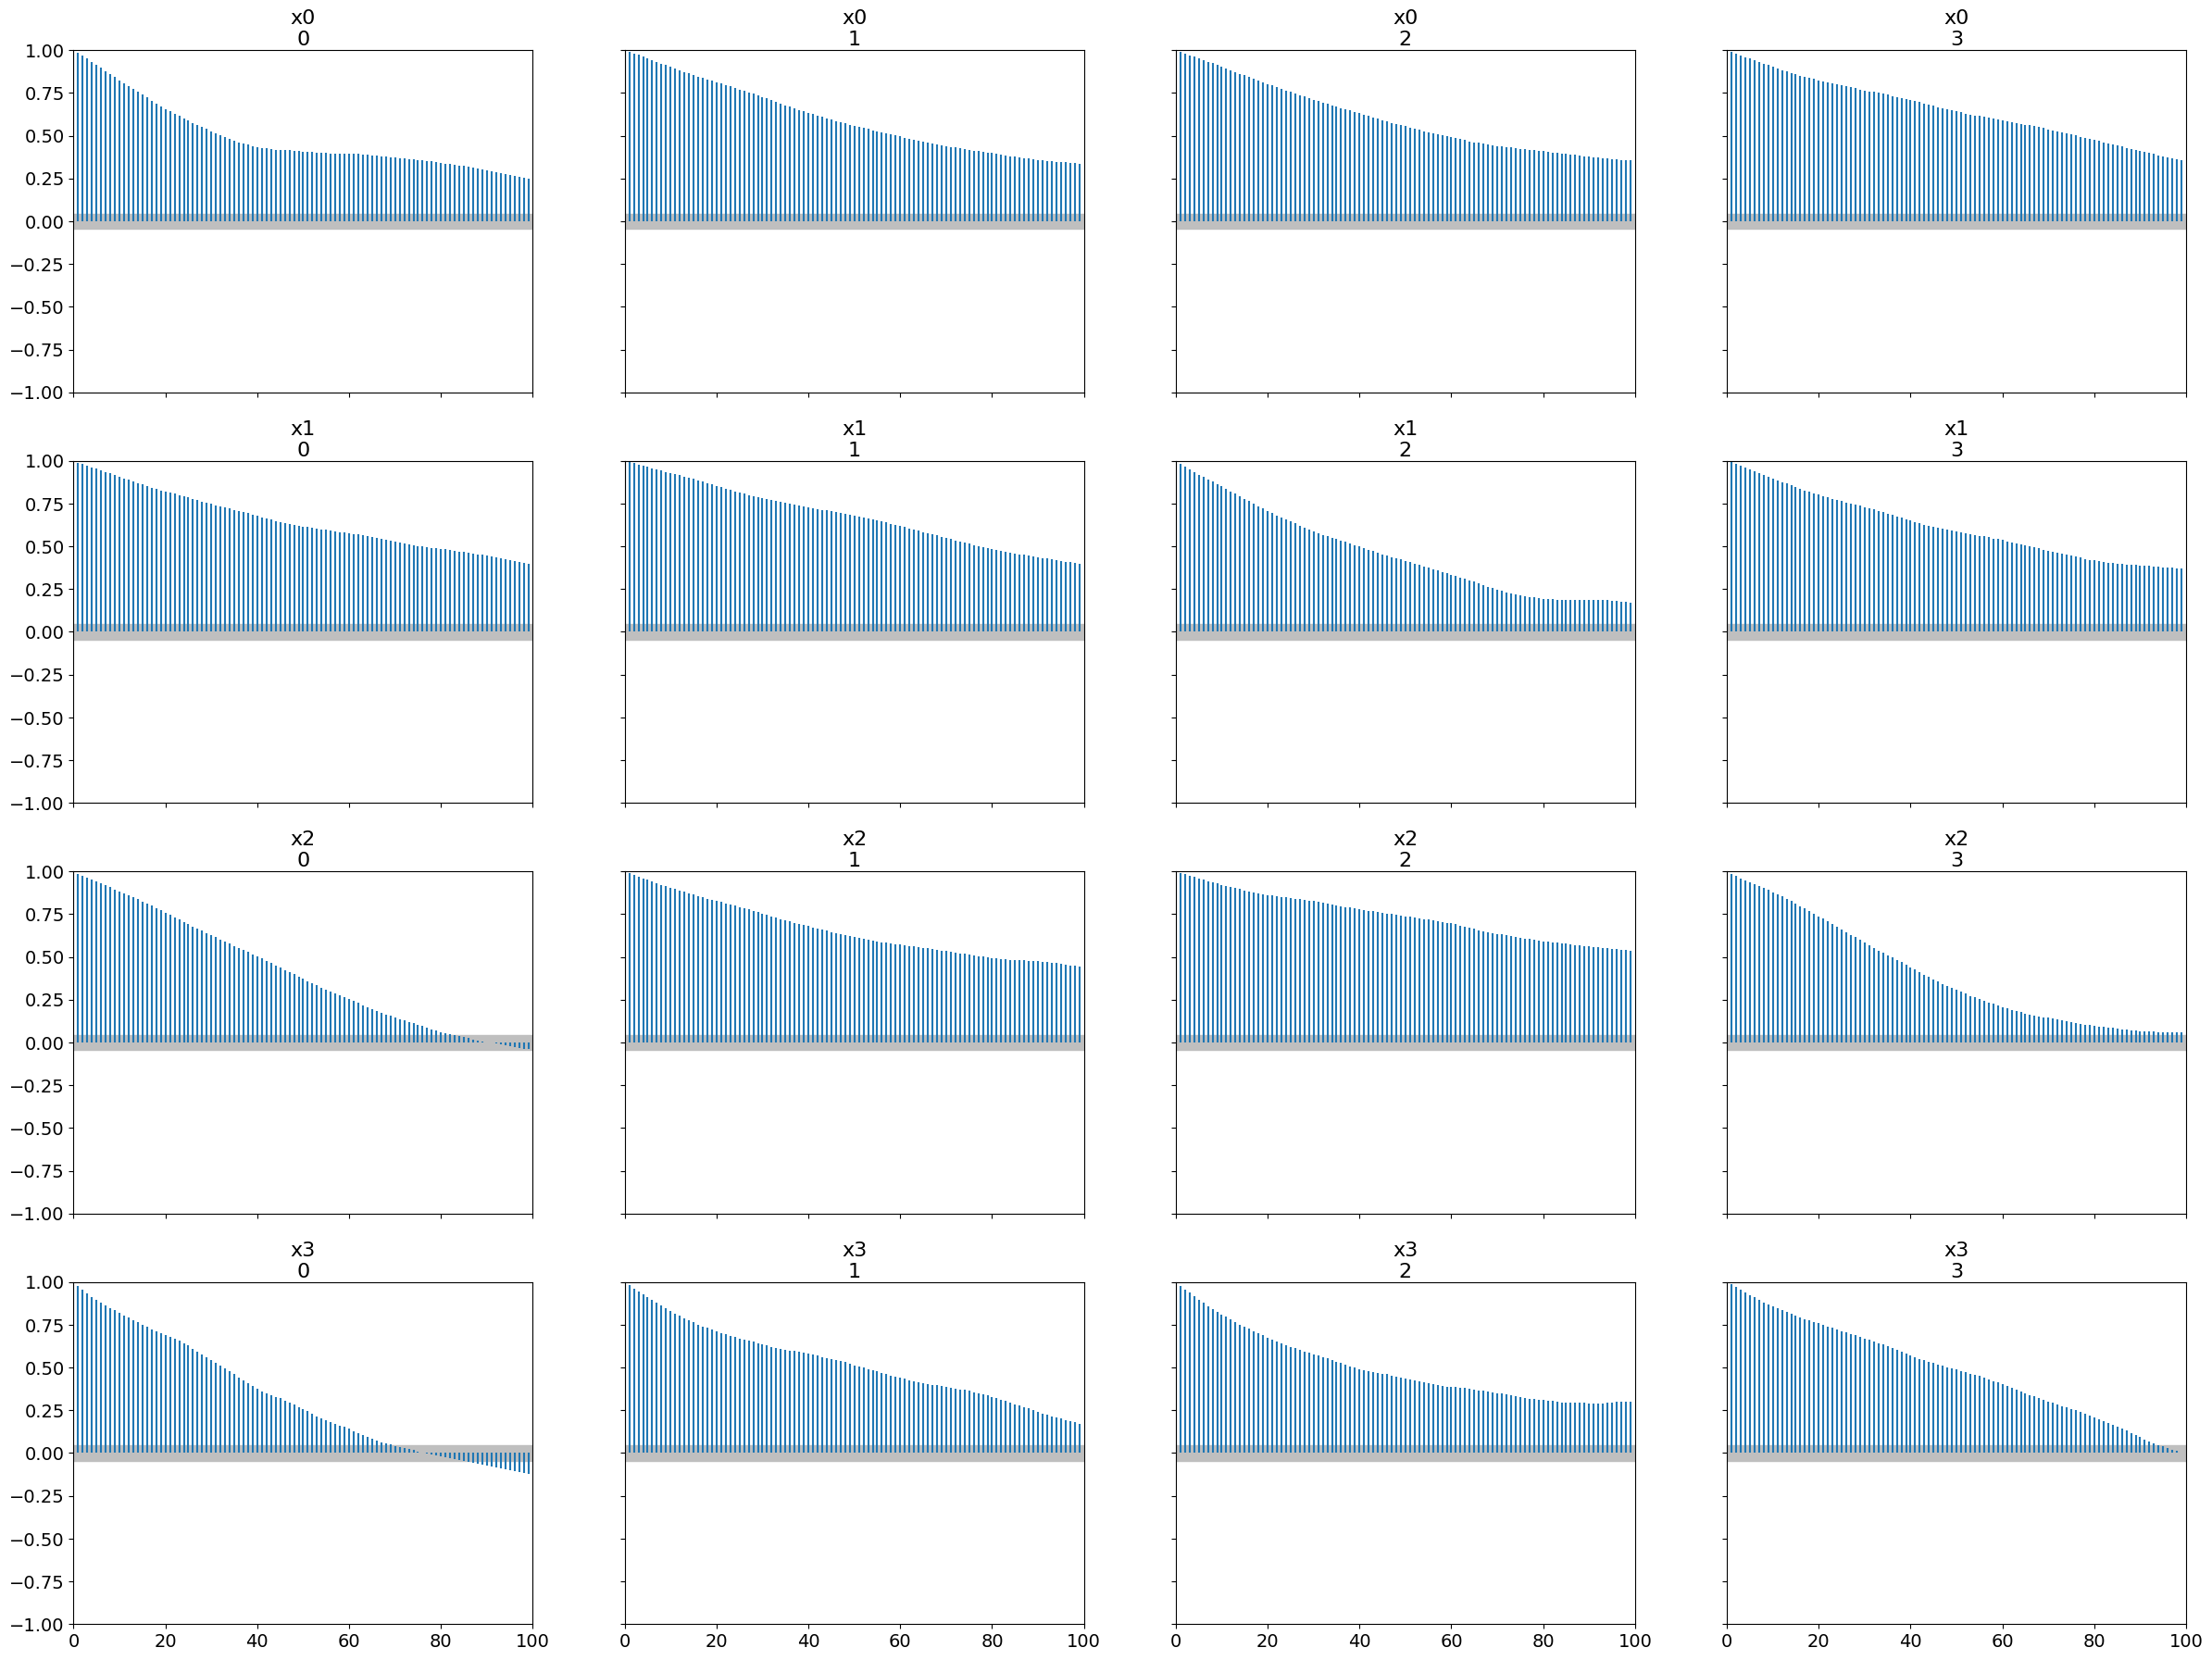

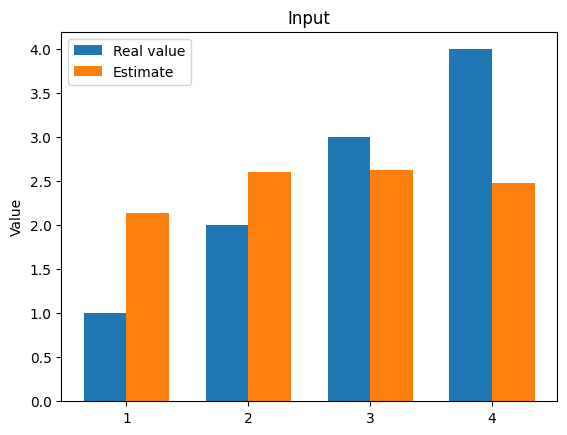

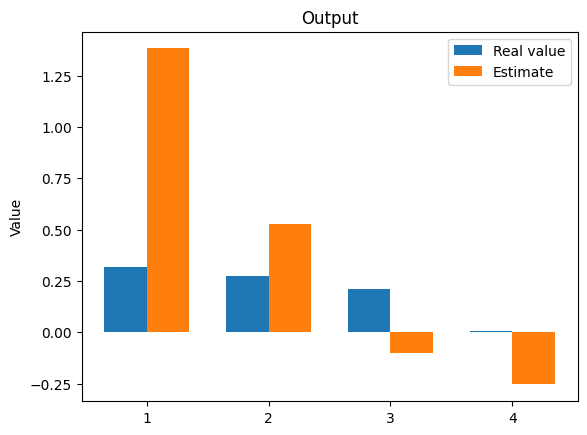

The function inverse took 1096.192230939865 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.91: 100%|██████████| 5000/5000 [04:30<00:00, 18.48it/s]


Sampling chain 2/4


Running chain, α = 0.92: 100%|██████████| 5000/5000 [04:41<00:00, 17.78it/s]


Sampling chain 3/4


Running chain, α = 0.93: 100%|██████████| 5000/5000 [04:20<00:00, 19.19it/s]


Sampling chain 4/4


Running chain, α = 0.85: 100%|██████████| 5000/5000 [04:05<00:00, 20.37it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.138 2.4   2.523 2.849]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.138  0.645   0.835    3.213      0.095    0.068      45.0     112.0   
x1  2.400  0.622   1.233    3.478      0.148    0.107      18.0      29.0   
x2  2.523  0.585   1.404    3.758      0.134    0.096      20.0      93.0   
x3  2.849  0.656   1.645    4.103      0.104    0.074      40.0     105.0   

    r_hat  
x0   1.11  
x1   1.17  
x2   1.15  
x3   1.12  
Autocorrelation...
the estimated values are [1.138 0.4   0.477 1.151]
 the difference between outputs of two models are [0.39209688 0.11457032 0.34820402 0.5388322 ]


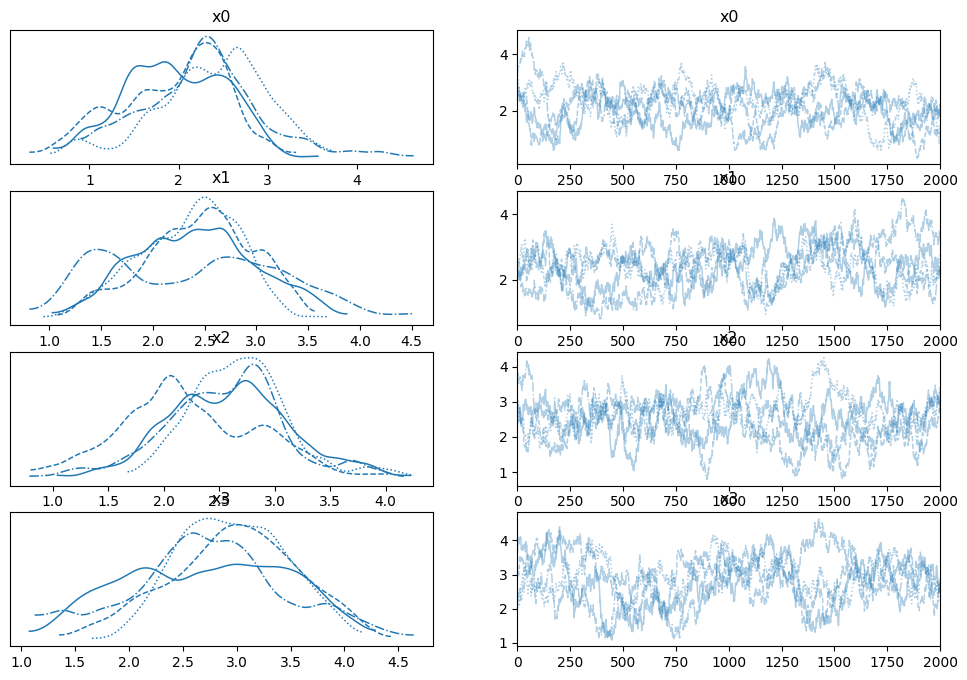

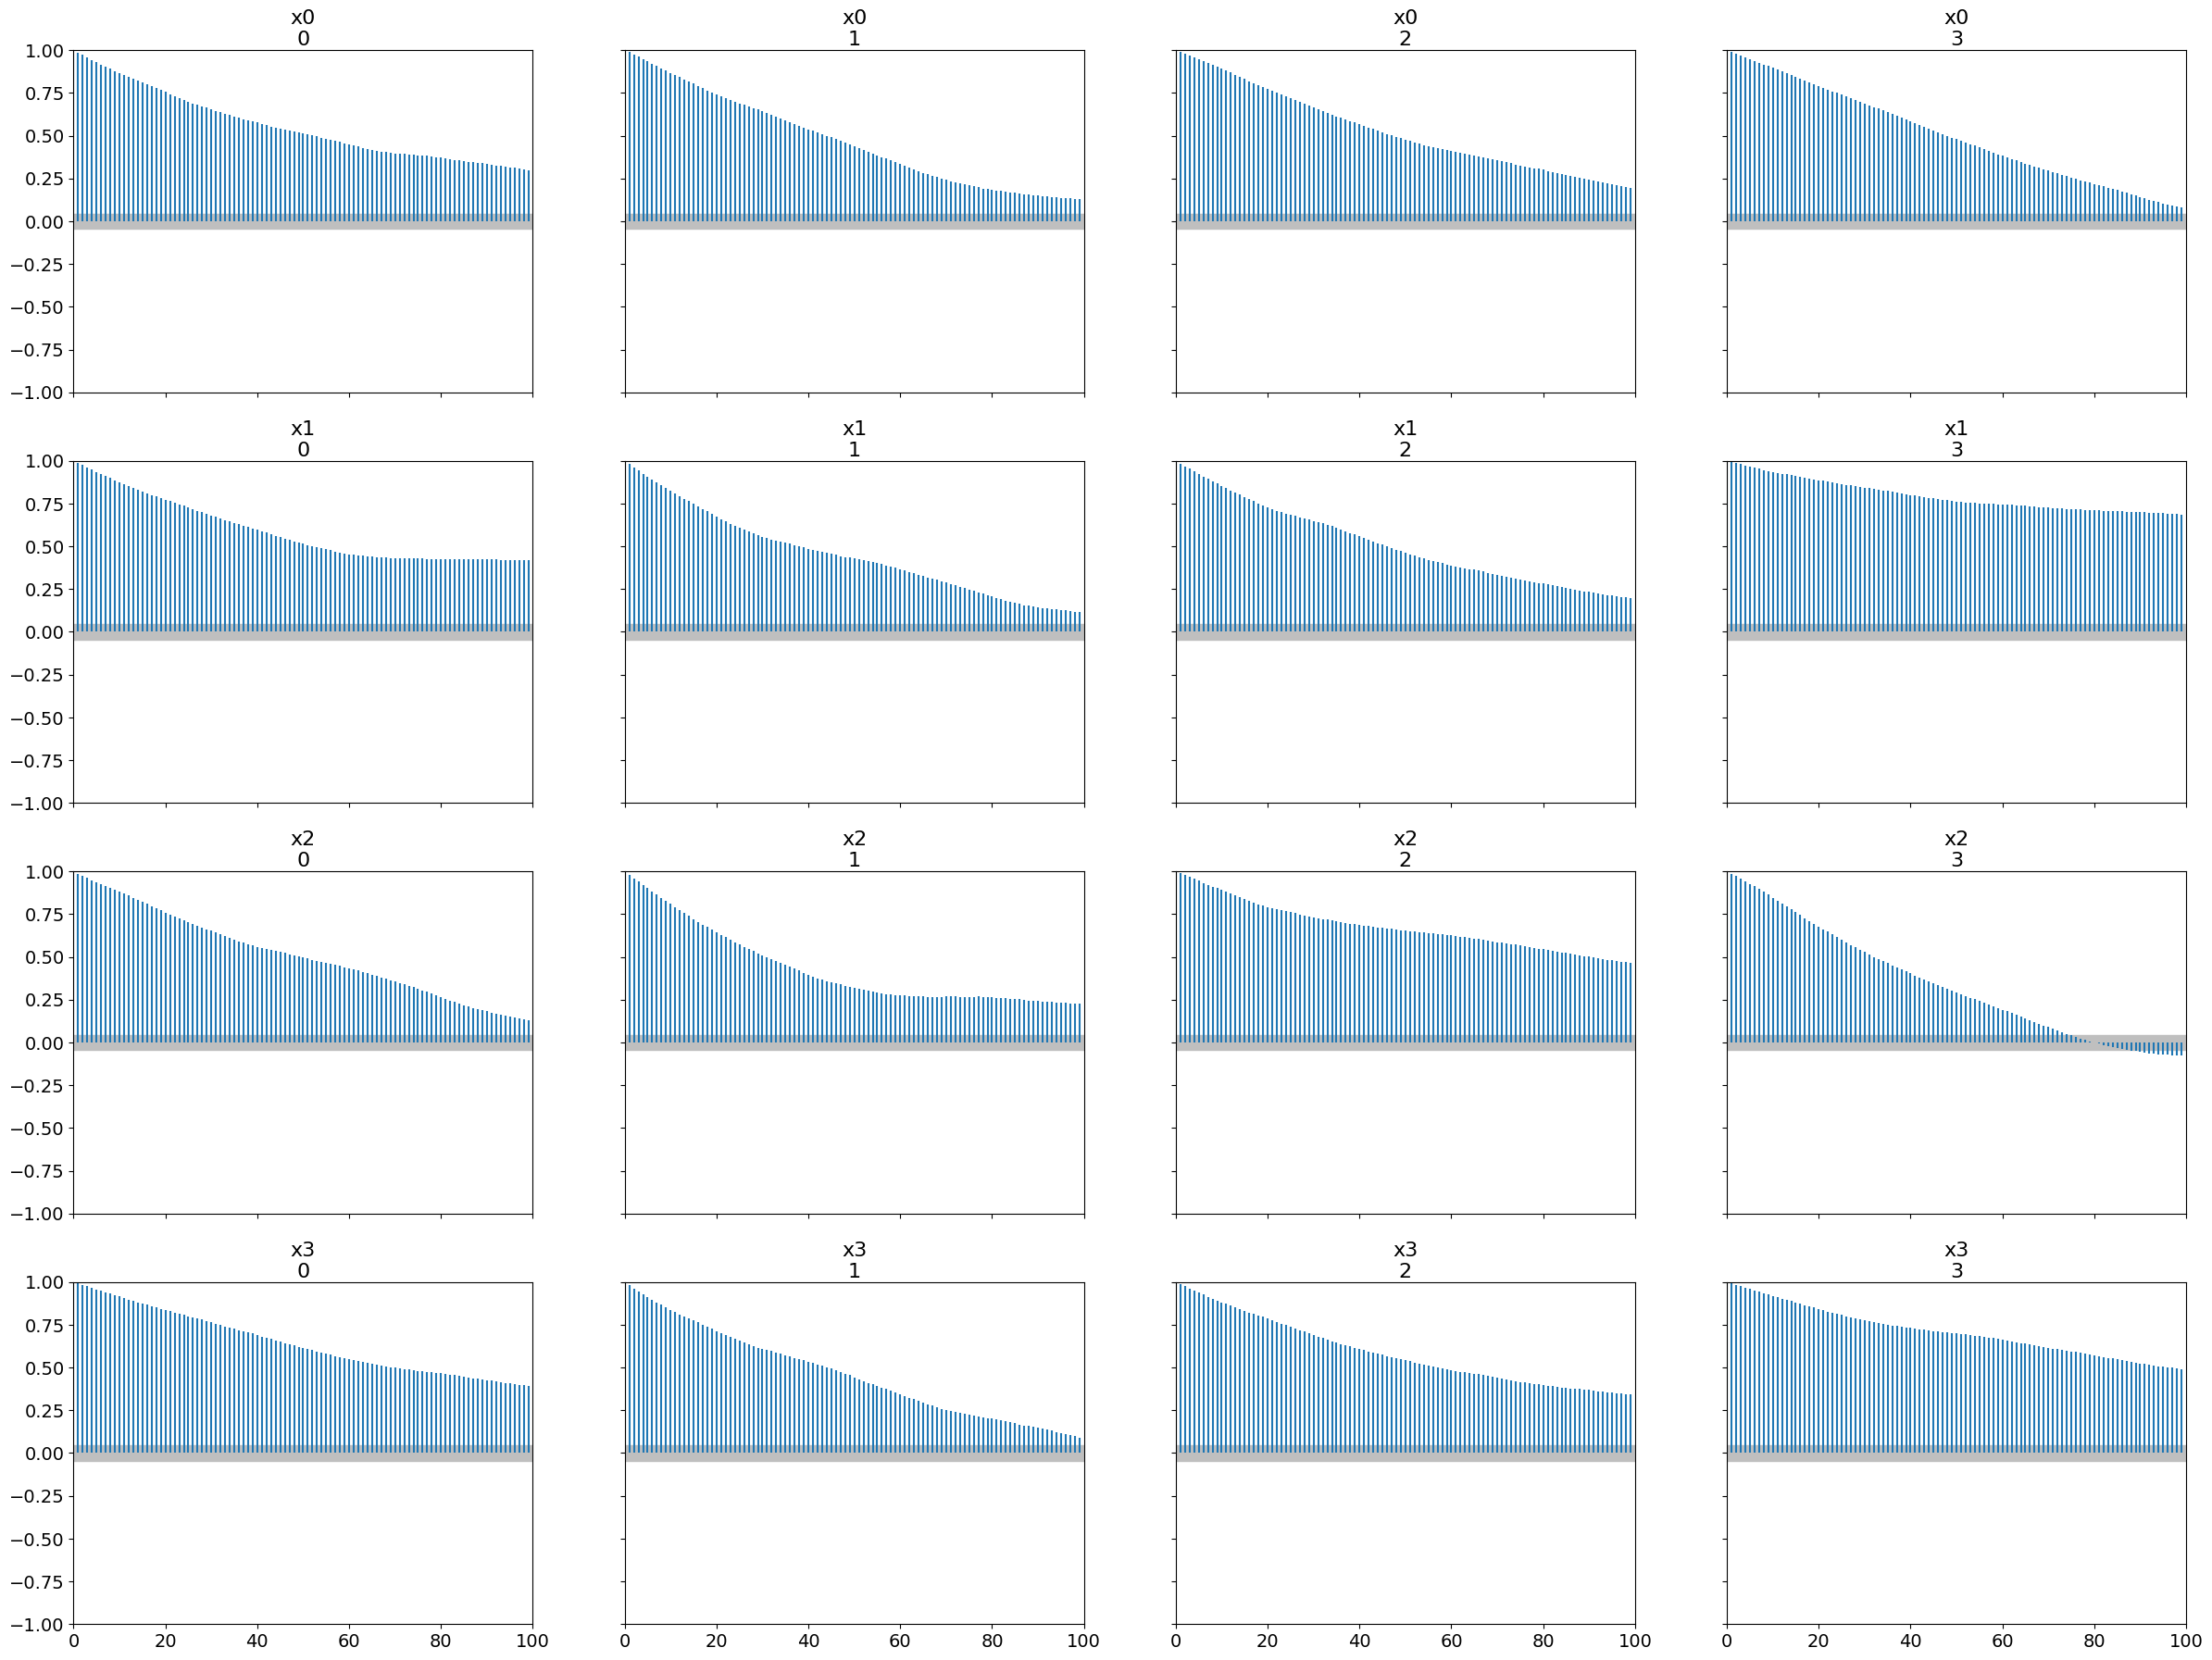

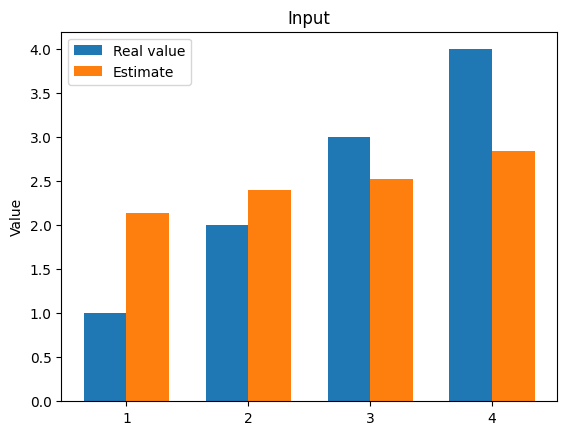

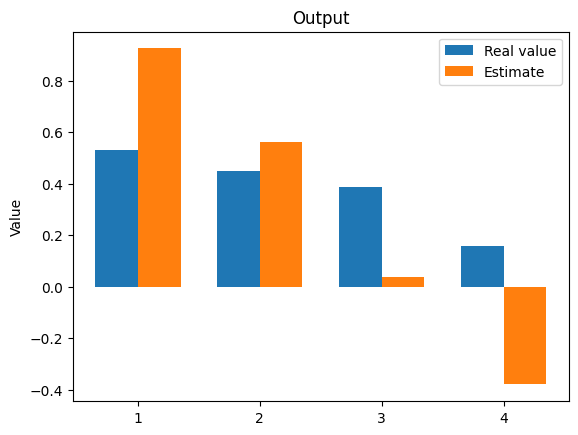

The function inverse took 1077.0690531730652 seconds.


In [27]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=cov_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=cov_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=cov_noise, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

### Adaptive Metropolis Hastings

# MCMC using CuqiPy

In [11]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.2
#rwmh_cov = np.eye(len(real_x)) # !

iterations =4000
burnin = 3000
n_chains=2

In [12]:
estimate_MF=final_model.inverse_cuqi(mean_prior, sd_noise=sigma, proposal_sd=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)
estimate_LF=modelLF.inverse_cuqi(mean_prior, sd_noise=sigma, proposal_sd=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)
estimate_HF=modelHF.inverse_cuqi(mean_prior, sd_noise=sigma, proposal_sd=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True)


Sample 3840 / 4000

KeyboardInterrupt: 

### Reducing the standard deviation of the posterior

In [12]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =5000
burnin = 1500
n_chains=2

real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.74: 100%|██████████| 5000/5000 [07:23<00:00, 11.27it/s]


Sampling chain 2/2


Running chain, α = 0.77: 100%|██████████| 5000/5000 [07:23<00:00, 11.28it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.382 2.264 2.611 3.256]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.382  0.385   0.666    2.116      0.042    0.031      83.0     152.0   
x1  2.264  0.453   1.453    3.107      0.058    0.041      62.0     198.0   
x2  2.611  0.433   1.759    3.374      0.079    0.057      28.0     210.0   
x3  3.256  0.448   2.366    4.054      0.059    0.042      59.0     131.0   

    r_hat  
x0   1.03  
x1   1.01  
x2   1.10  
x3   1.01  
Autocorrelation...
the estimated values are [0.382 0.264 0.389 0.744]
 the difference between outputs of two models are [0.21216381 0.18922609 0.21707673 0.3678261 ]


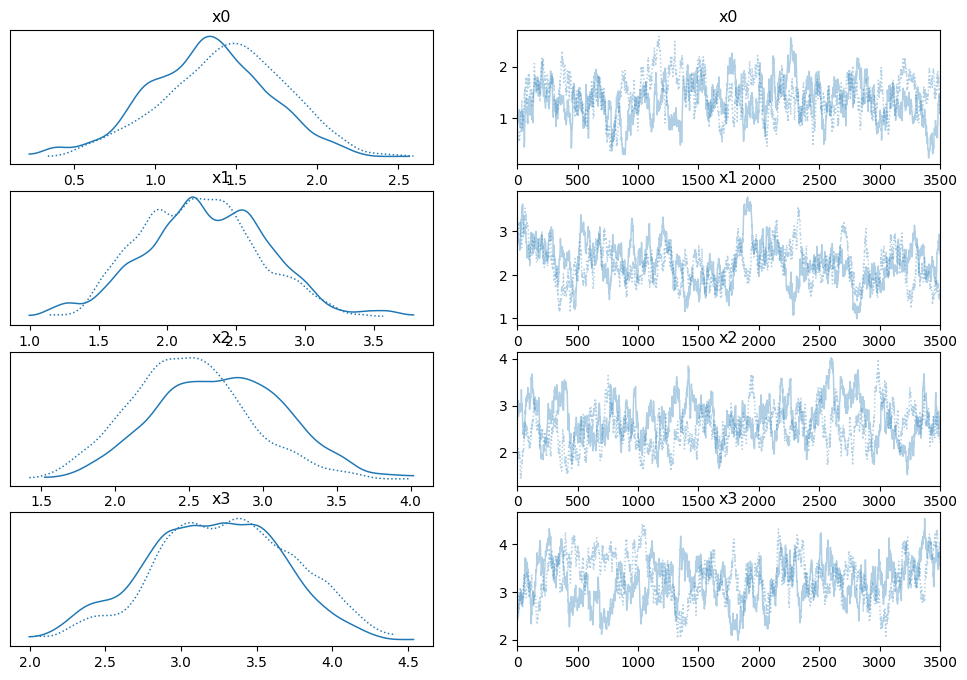

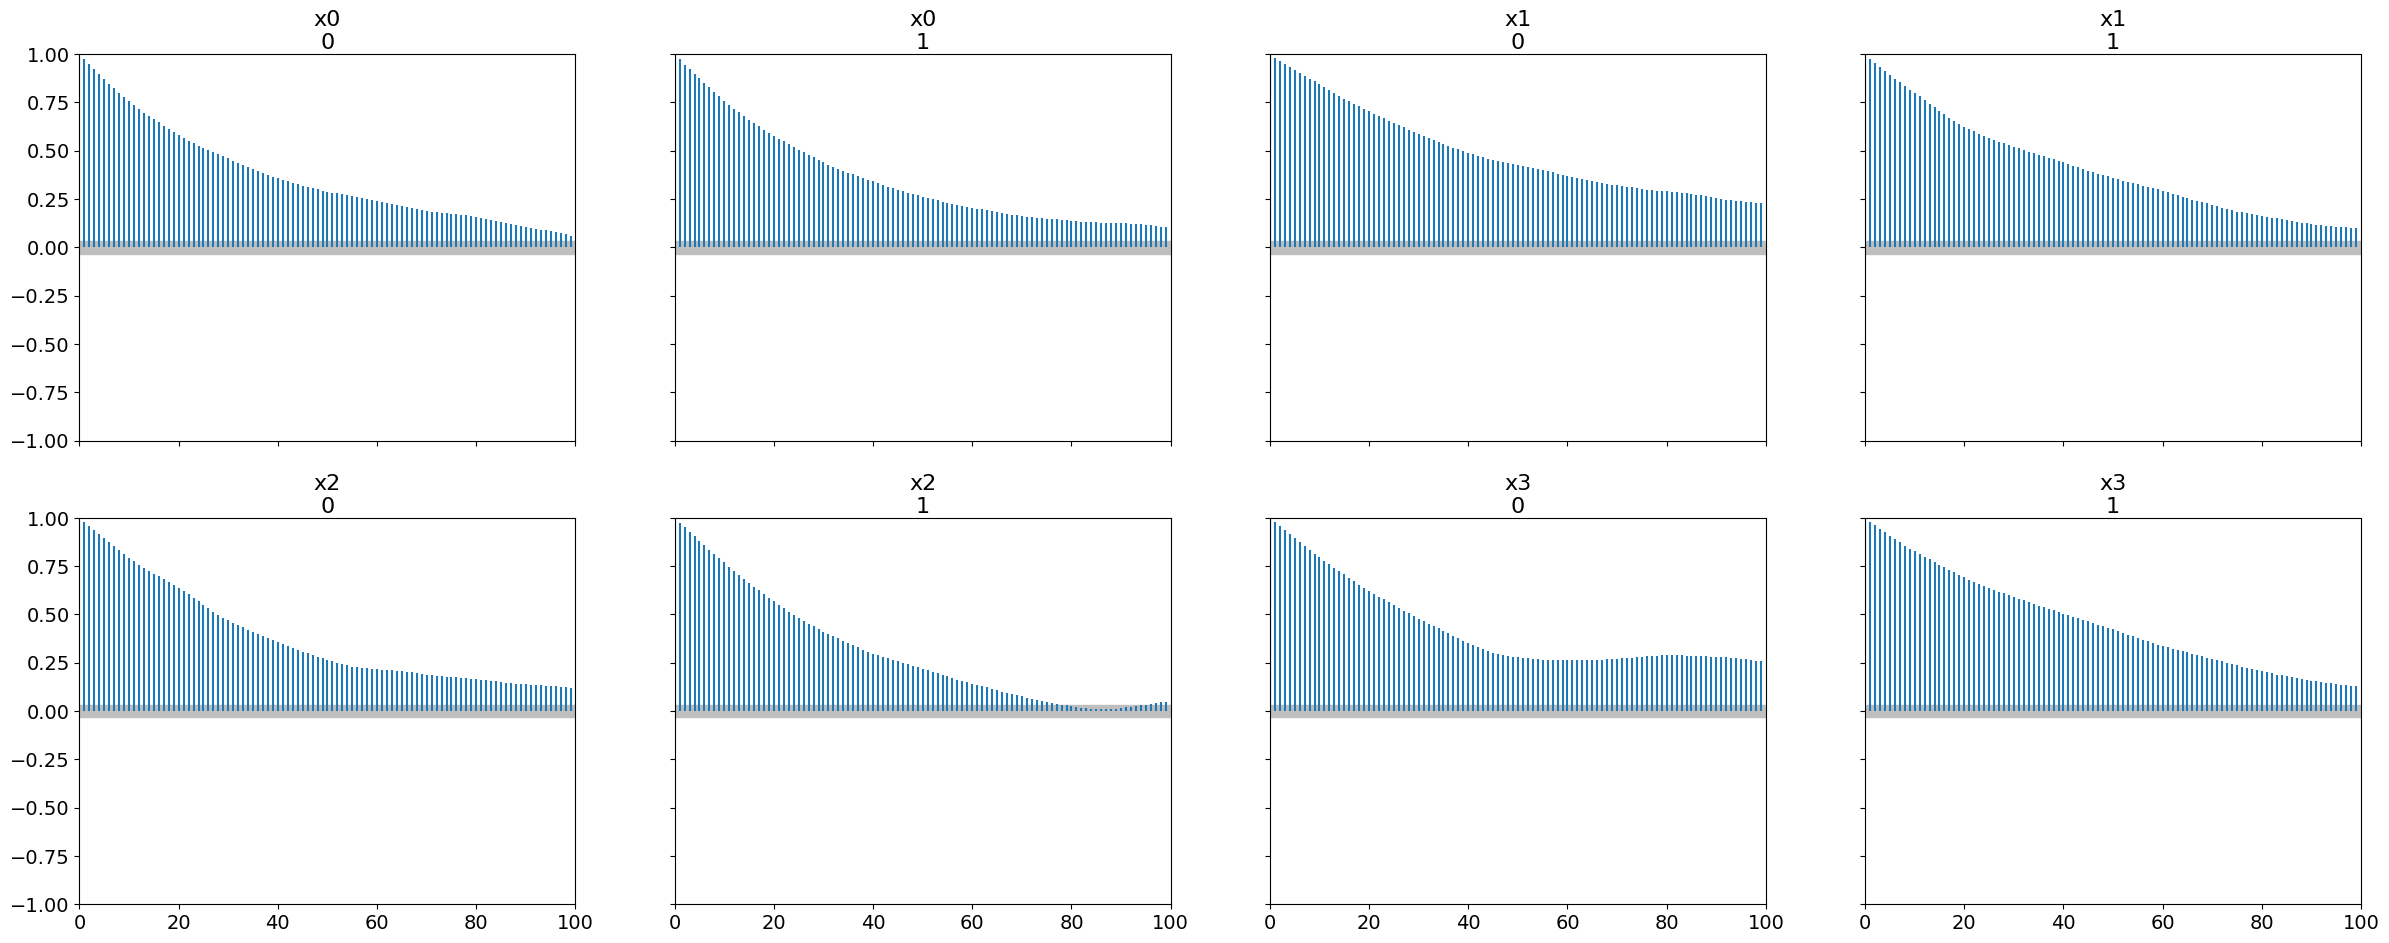

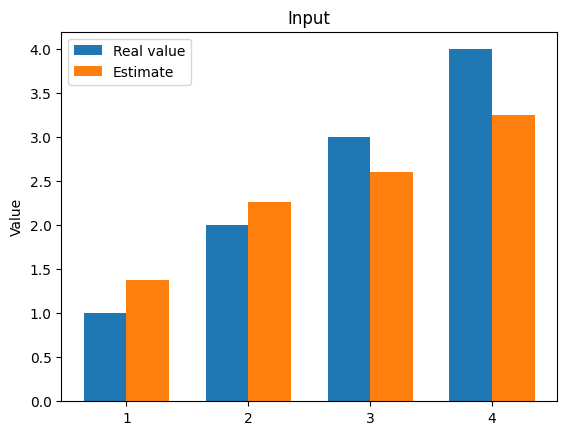

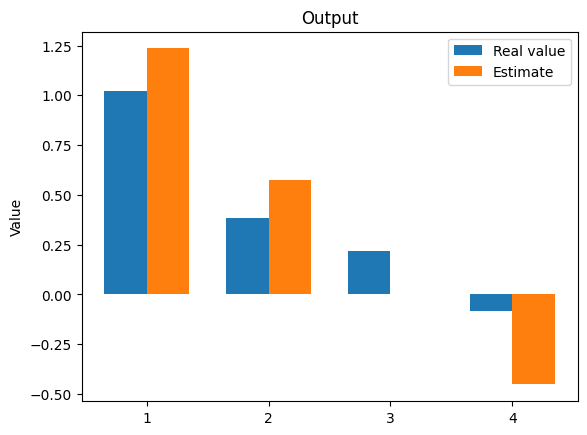

The function inverse took 906.032173871994 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.78: 100%|██████████| 5000/5000 [03:49<00:00, 21.77it/s]


Sampling chain 2/2


Running chain, α = 0.74: 100%|██████████| 5000/5000 [03:47<00:00, 22.00it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.451 2.586 2.615 3.023]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.451  0.316   0.811    1.982      0.028    0.020     129.0     215.0   
x1  2.586  0.524   1.892    3.800      0.080    0.057      49.0     123.0   
x2  2.615  0.518   1.881    3.664      0.141    0.102      13.0      84.0   
x3  3.023  0.520   2.300    4.093      0.137    0.099      15.0     104.0   

    r_hat  
x0   1.01  
x1   1.04  
x2   1.10  
x3   1.12  
Autocorrelation...
the estimated values are [0.451 0.586 0.385 0.977]
 the difference between outputs of two models are [0.04838049 0.2191081  0.3401382  0.16070125]


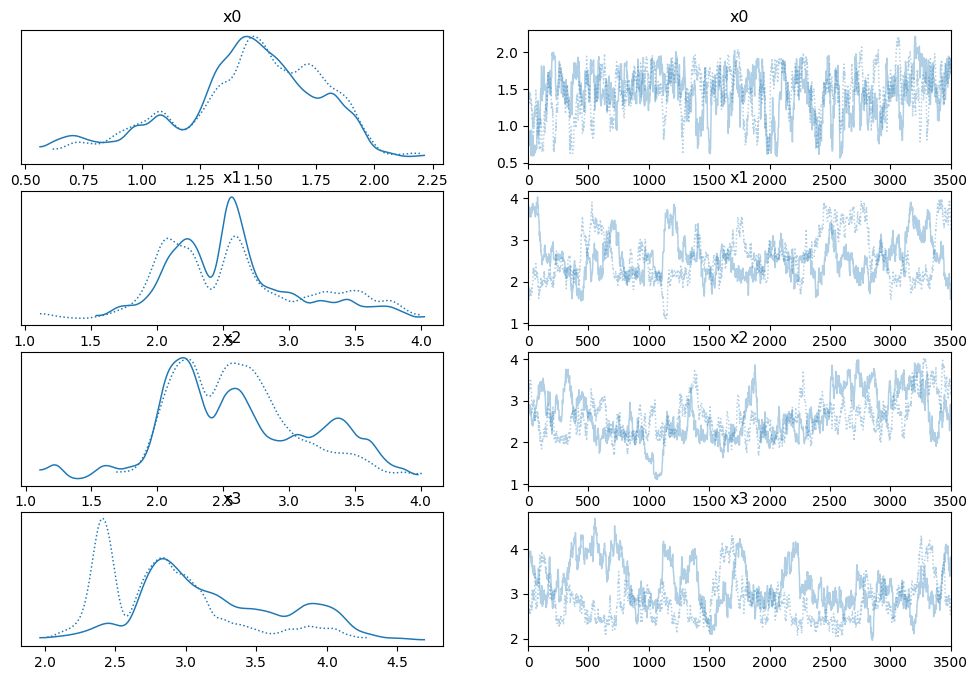

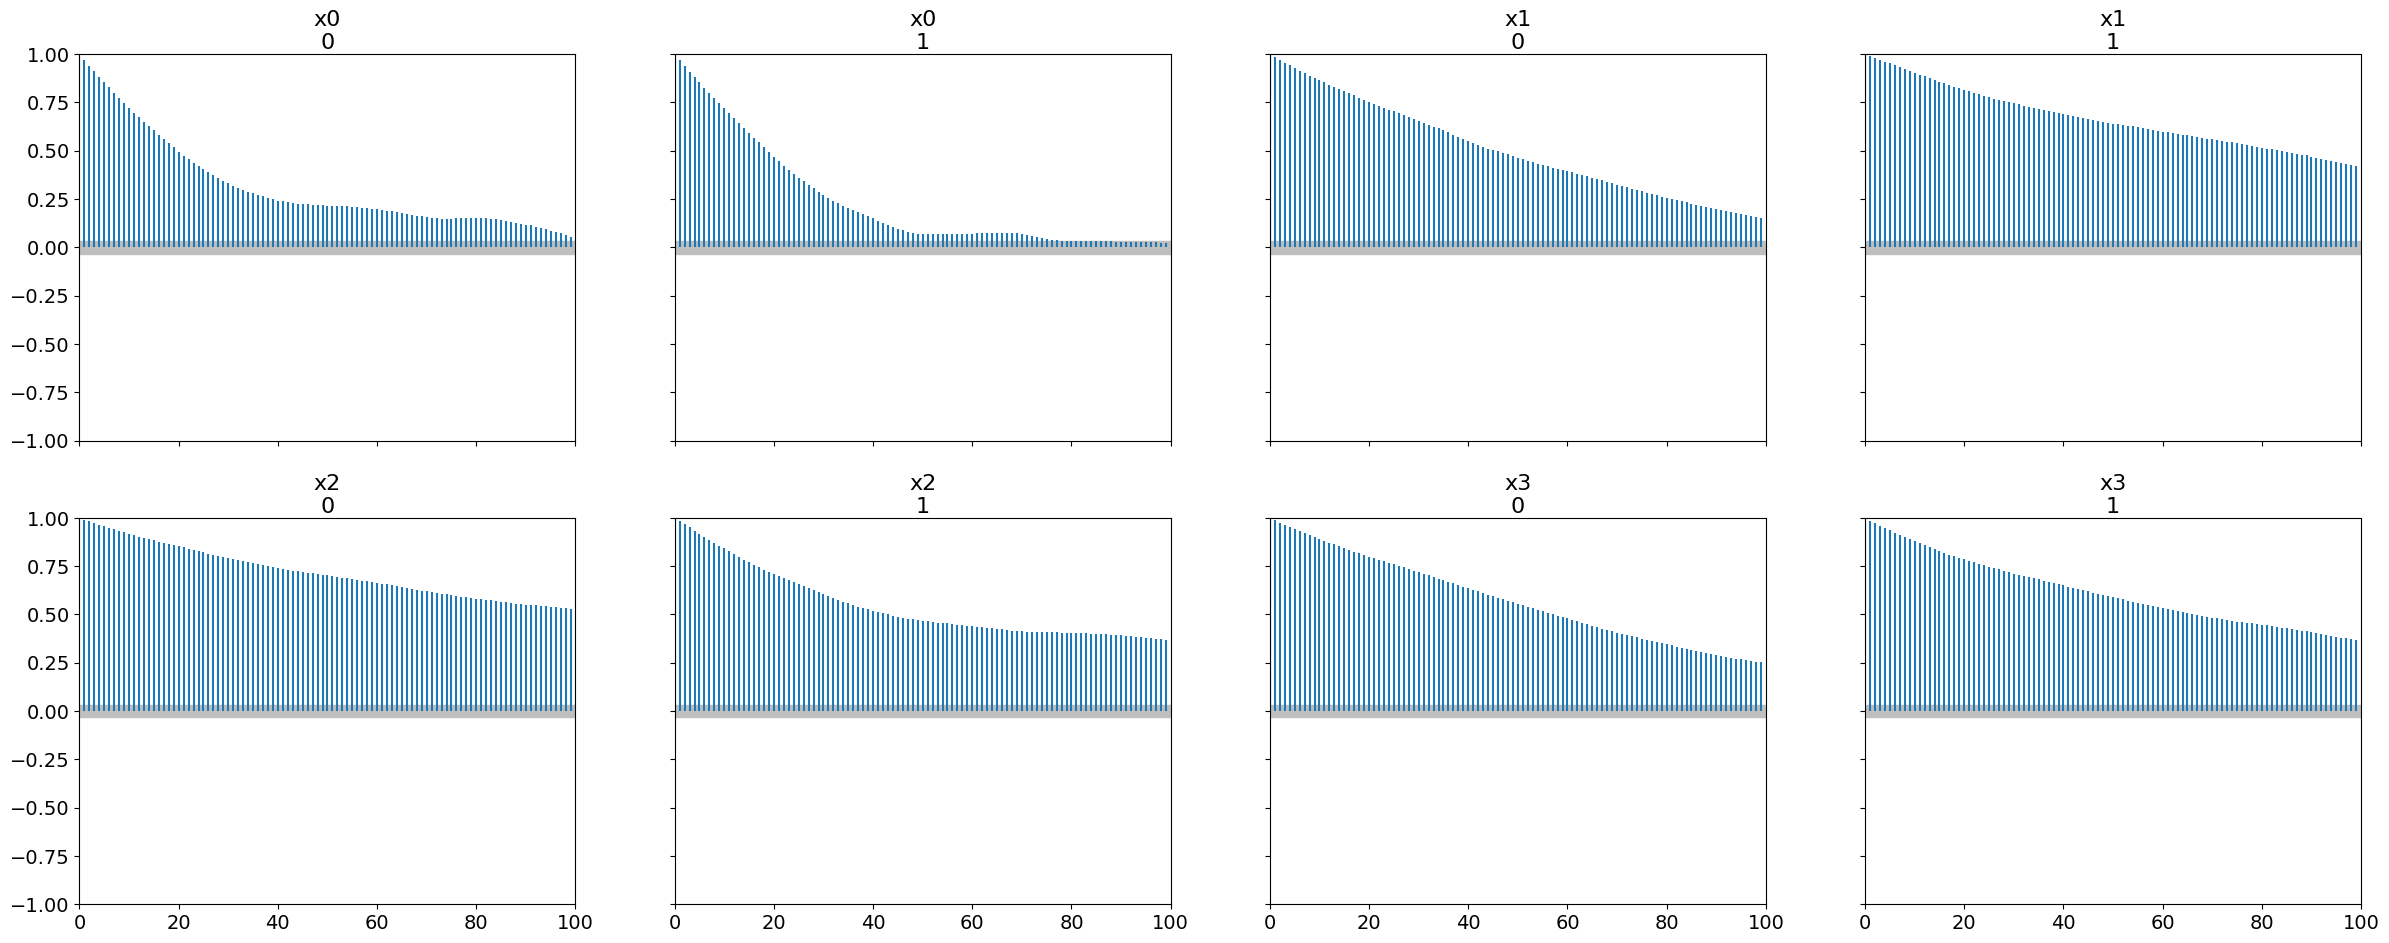

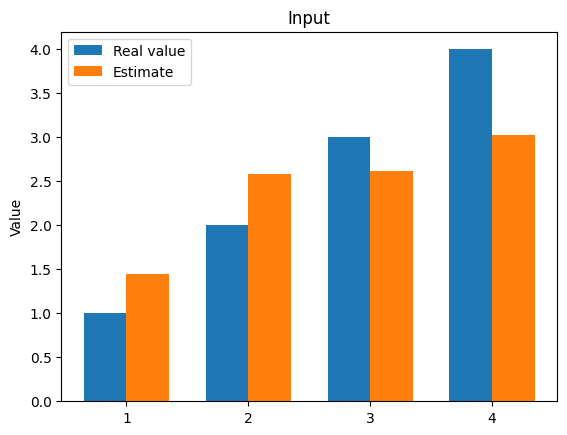

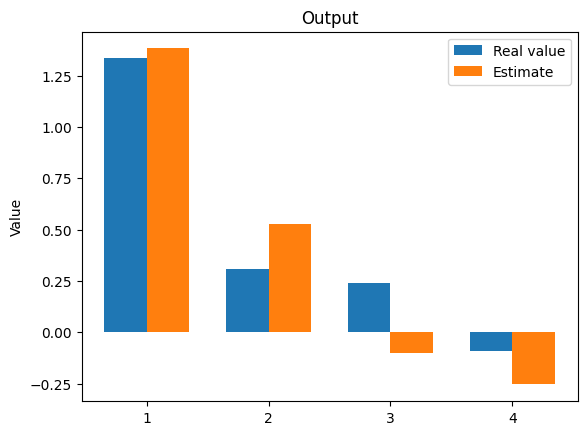

The function inverse took 472.1435754299164 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/2


Running chain, α = 0.72: 100%|██████████| 5000/5000 [03:45<00:00, 22.15it/s]


Sampling chain 2/2


Running chain, α = 0.87: 100%|██████████| 5000/5000 [03:45<00:00, 22.20it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.179 2.236 2.79  3.366]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.179  0.509   0.580    2.139      0.080    0.057      53.0     157.0   
x1  2.236  0.483   1.227    3.009      0.074    0.053      46.0     144.0   
x2  2.790  0.563   1.623    3.754      0.100    0.071      34.0      58.0   
x3  3.366  0.390   2.656    4.135      0.042    0.030      90.0     237.0   

    r_hat  
x0   1.05  
x1   1.02  
x2   1.05  
x3   1.03  
Autocorrelation...
the estimated values are [0.179 0.236 0.21  0.634]
 the difference between outputs of two models are [0.18956786 0.05577302 0.16692202 0.19767542]


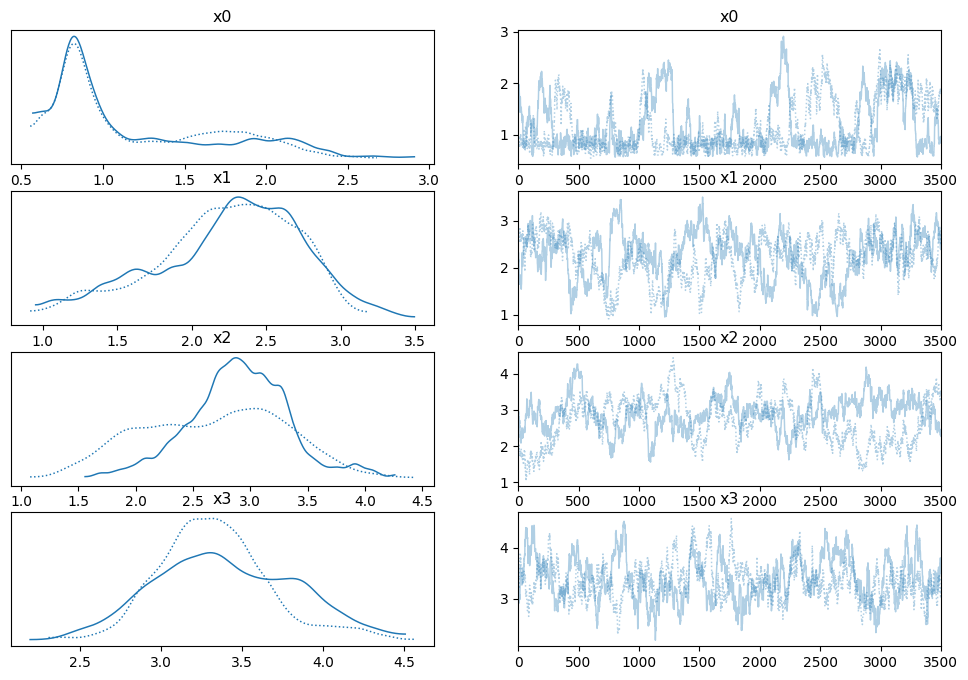

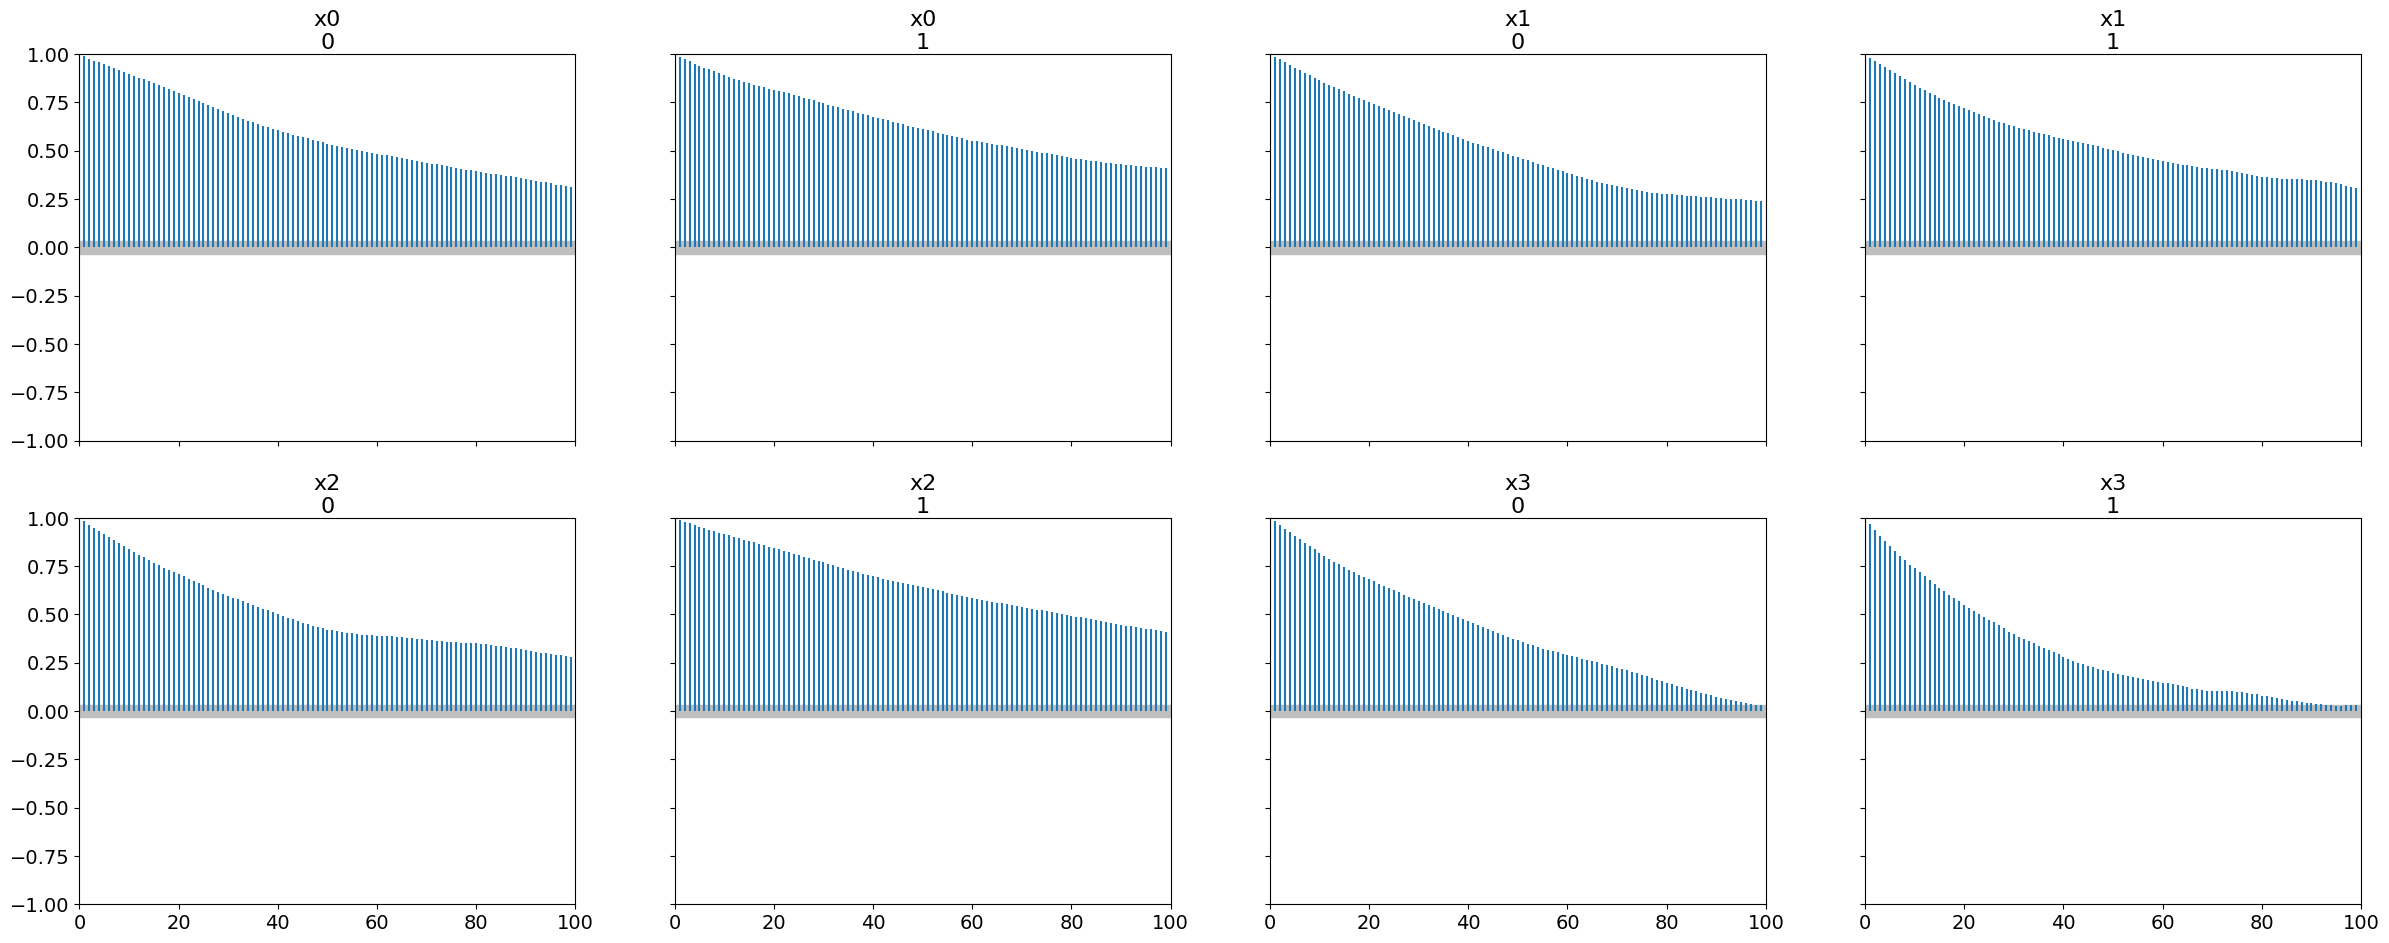

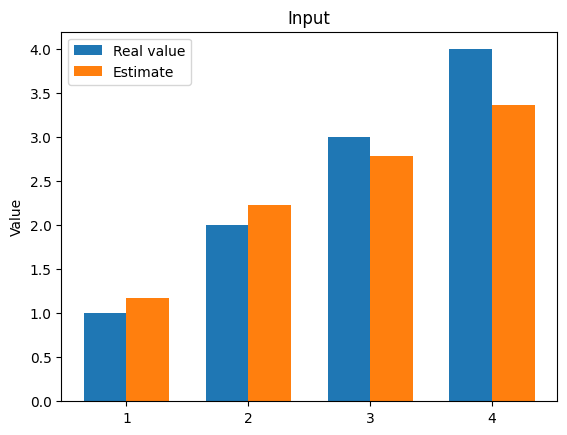

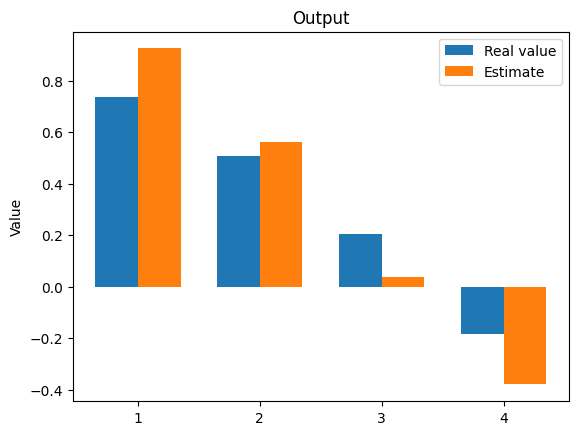

The function inverse took 462.08625316619873 seconds.


In [13]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)



HF similar to MF, but more vaariance

### Adding more chains

In [14]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =5000
burnin = 1500
n_chains=4

real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.86: 100%|██████████| 5000/5000 [07:07<00:00, 11.71it/s]


Sampling chain 2/4


Running chain, α = 0.83: 100%|██████████| 5000/5000 [07:02<00:00, 11.83it/s]


Sampling chain 3/4


Running chain, α = 0.85: 100%|██████████| 5000/5000 [07:09<00:00, 11.64it/s]


Sampling chain 4/4


Running chain, α = 0.78: 100%|██████████| 5000/5000 [07:10<00:00, 11.61it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.372 2.449 2.621 3.188]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.372  0.380   0.664    2.100      0.030    0.021     161.0     291.0   
x1  2.449  0.442   1.646    3.313      0.036    0.026     151.0     291.0   
x2  2.621  0.412   1.862    3.417      0.031    0.022     175.0     411.0   
x3  3.188  0.479   2.253    4.015      0.044    0.031     120.0     338.0   

    r_hat  
x0   1.04  
x1   1.02  
x2   1.01  
x3   1.03  
Autocorrelation...
the estimated values are [0.372 0.449 0.379 0.812]
 the difference between outputs of two models are [0.20661545 0.28987908 0.21221758 0.3945763 ]


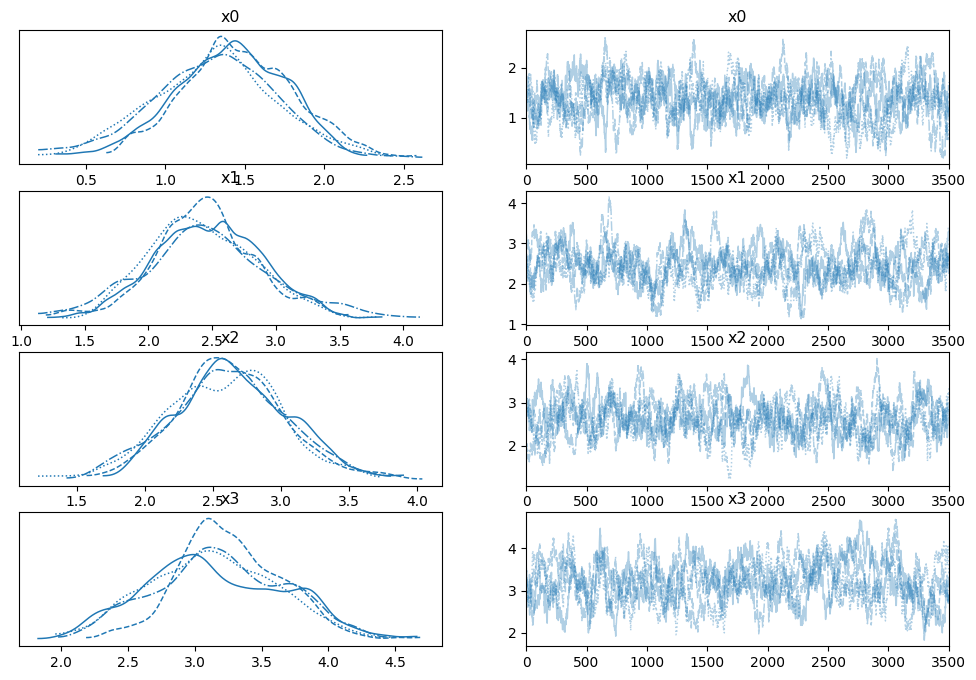

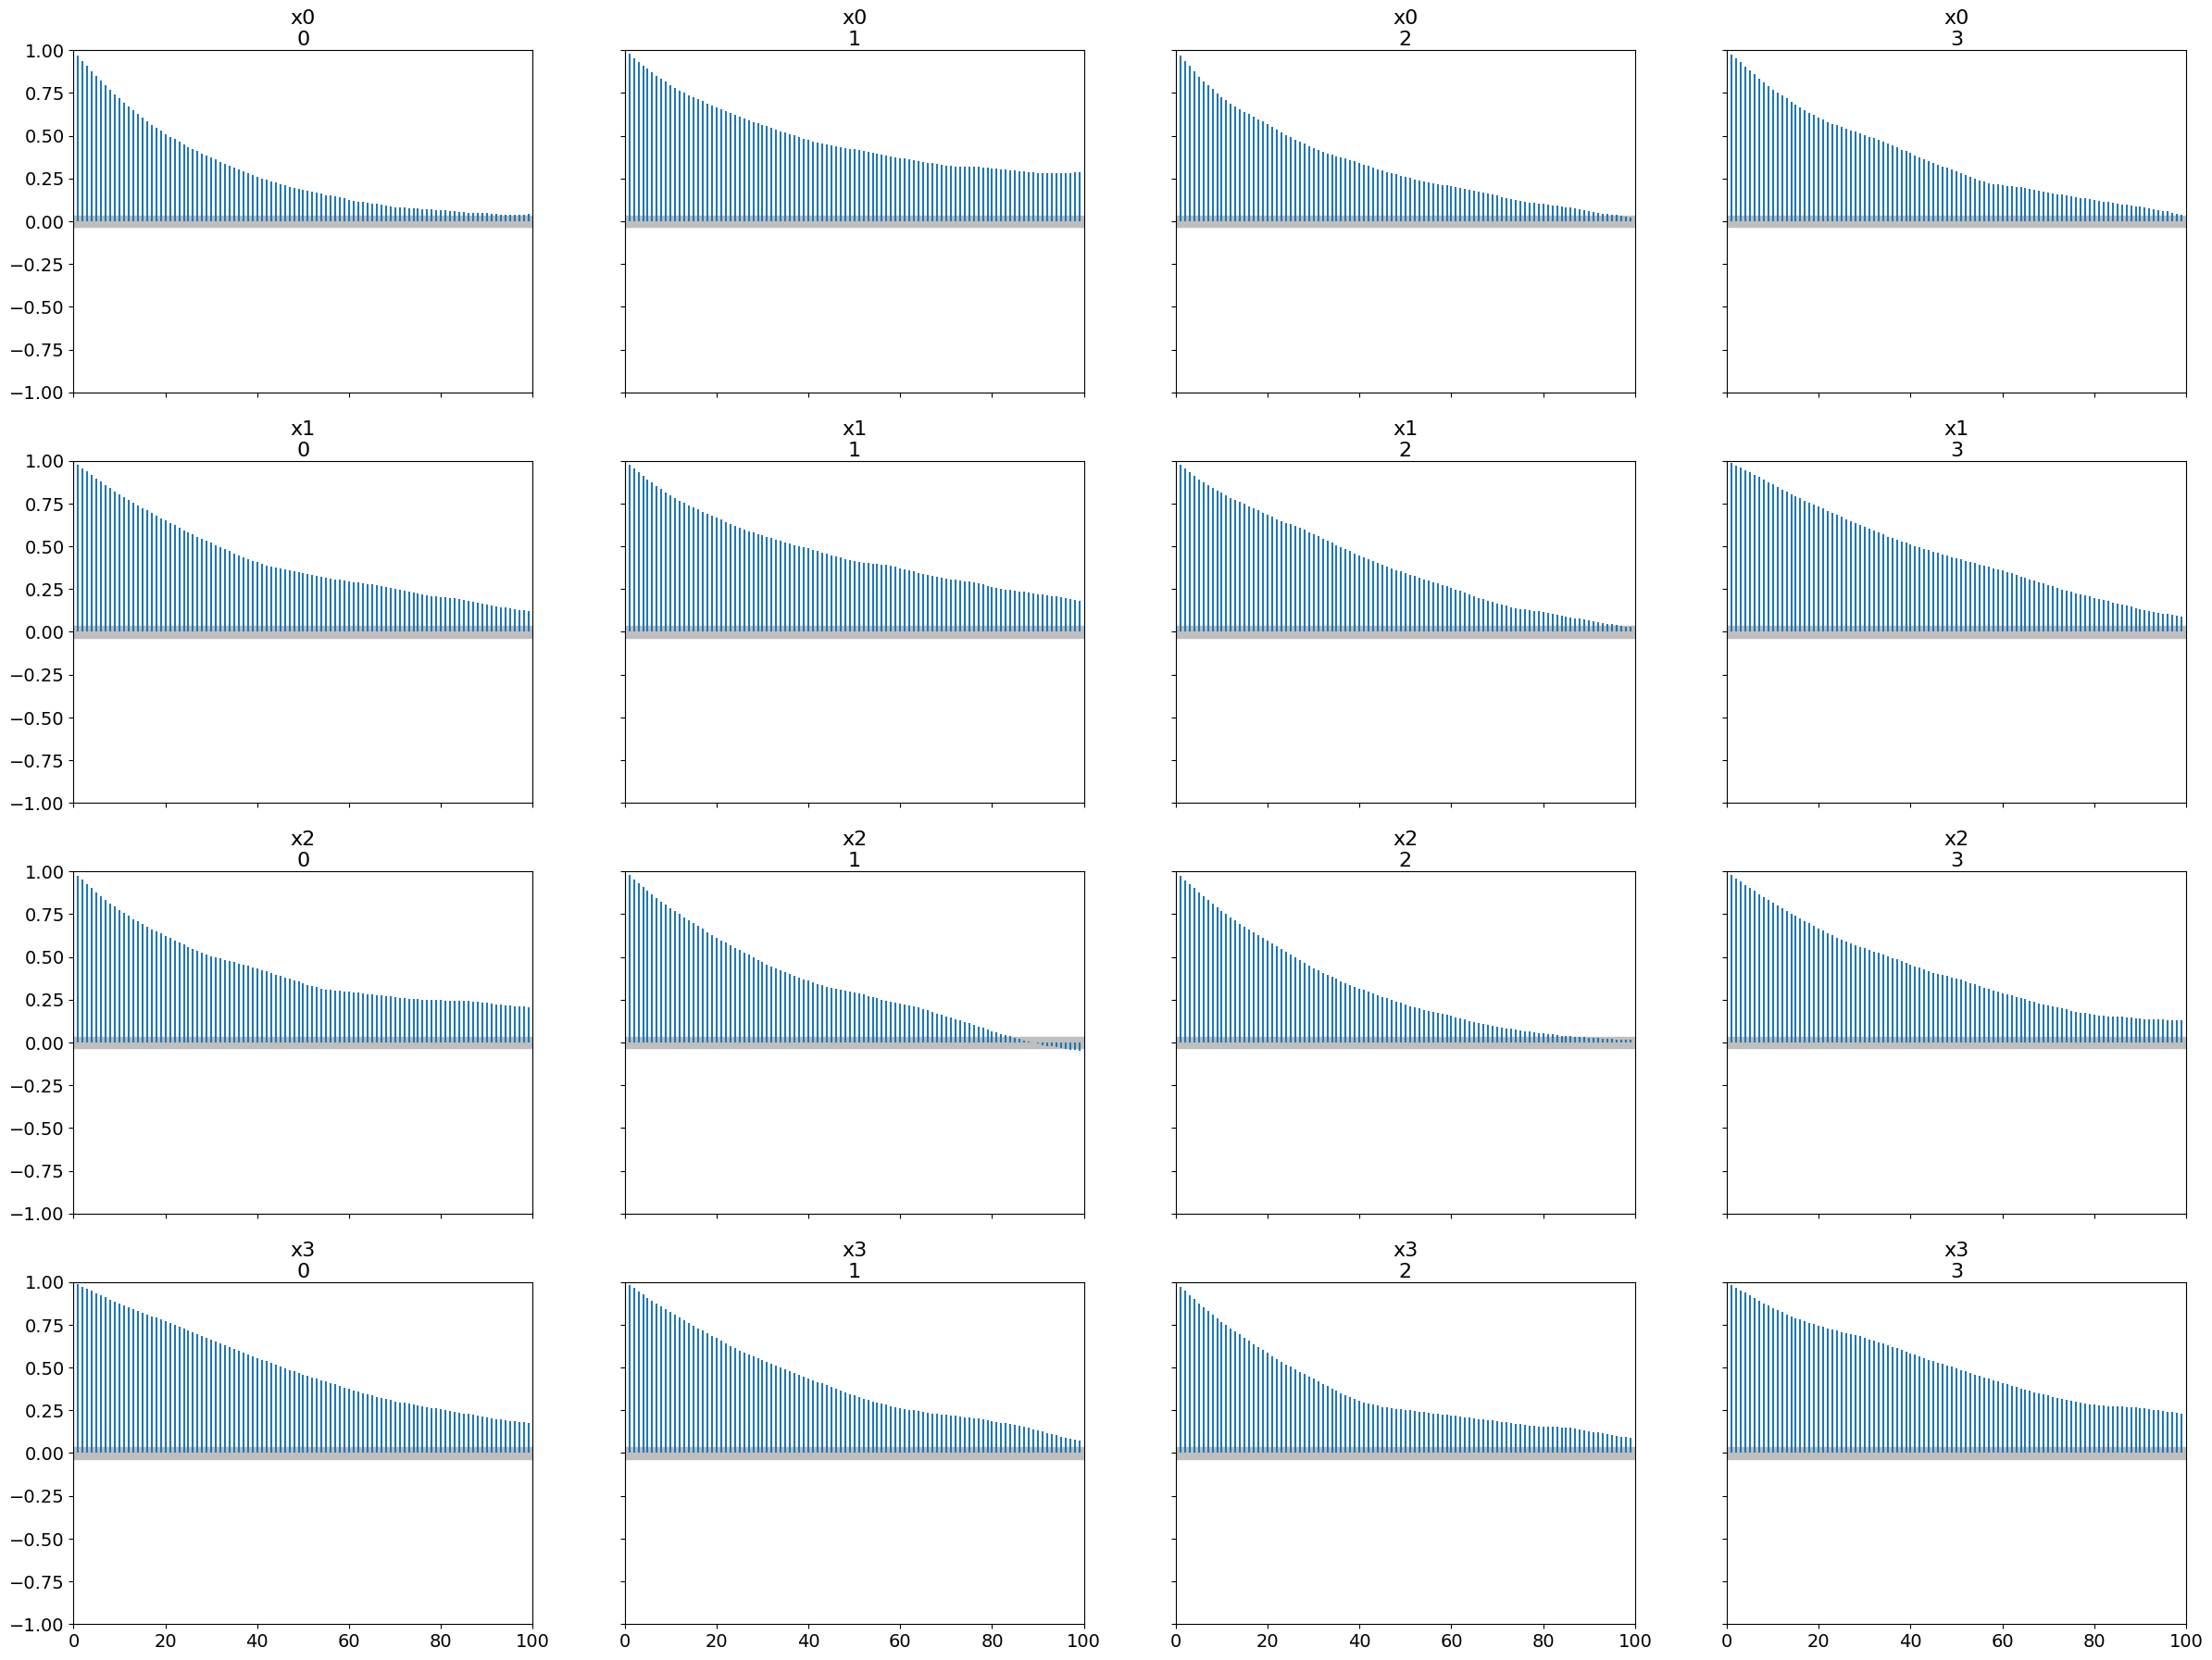

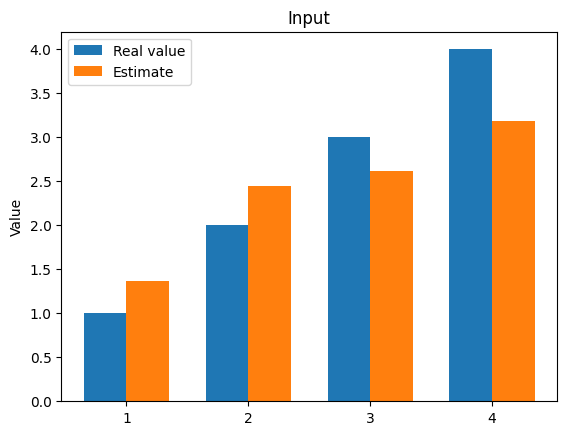

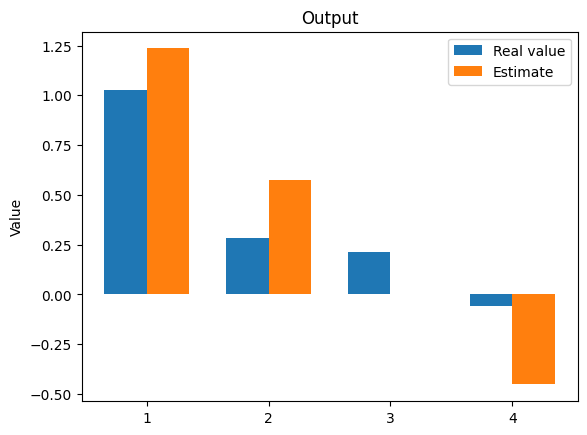

The function inverse took 1713.010972738266 seconds.


In [15]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
